In [2]:
import requests 
import csv
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [3]:
df= pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [4]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [5]:
print("=" * 50)
print("ÉTAPE 1: DATA CLEANING")
print("=" * 50)

ÉTAPE 1: DATA CLEANING


In [6]:
print("\n1. Aperçu du dataset:")
print(f"Dimensions: {df.shape[0]} lignes, {df.shape[1]} colonnes")
print("\nPremières lignes:")
df.head()



1. Aperçu du dataset:
Dimensions: 1470 lignes, 35 colonnes

Premières lignes:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [7]:
print("\n2. Vérification des valeurs manquantes:")
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("✓ Aucune valeur manquante détectée")
else:
    print("Valeurs manquantes par colonne:")
    print(missing_values[missing_values > 0])


2. Vérification des valeurs manquantes:
✓ Aucune valeur manquante détectée


In [8]:
print("\n3. Vérification des doublons:")
duplicates = df.duplicated().sum()
print(f"Nombre de lignes dupliquées: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"✓ {duplicates} doublons supprimés")
    print(f"Nouvelles dimensions: {df.shape}")
else:
    print("✓ Aucun doublon détecté")


3. Vérification des doublons:
Nombre de lignes dupliquées: 0
✓ Aucun doublon détecté


In [9]:
print("\n4. Types de données:")
df.dtypes



4. Types de données:


Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [10]:
print("\n5. Valeurs uniques pour les colonnes clés:")
critical_columns = ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 
                    'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
for col in critical_columns:
    if col in df.columns:
        print(f"{col}: {df[col].unique()}")



5. Valeurs uniques pour les colonnes clés:
Attrition: ['Yes' 'No']
BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
Department: ['Sales' 'Research & Development' 'Human Resources']
EducationField: ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
Gender: ['Female' 'Male']
JobRole: ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
MaritalStatus: ['Single' 'Married' 'Divorced']
OverTime: ['Yes' 'No']


In [11]:
print("\n6. Statistiques descriptives des colonnes numériques:")
df.describe()


6. Statistiques descriptives des colonnes numériques:


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [12]:
print("\n7. Détection des outliers:")
numeric_columns = df.select_dtypes(include=[np.number]).columns



7. Détection des outliers:


In [13]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

outlier_summary = []
for col in numeric_columns:
    if col not in ['EmployeeCount', 'StandardHours', 'EmployeeNumber']:  # Exclure les colonnes non pertinentes
        n_outliers, lower, upper = detect_outliers_iqr(df, col)
        if n_outliers > 0:
            outlier_summary.append({
                'Column': col,
                'Outliers': n_outliers,
                'Lower_Bound': lower,
                'Upper_Bound': upper
            })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary)
    print(outlier_df)
else:
    print("✓ Aucun outlier significatif détecté")


                    Column  Outliers  Lower_Bound  Upper_Bound
0            MonthlyIncome       114      -5291.0      16581.0
1       NumCompaniesWorked        52         -3.5          8.5
2        PerformanceRating       226          3.0          3.0
3         StockOptionLevel        85         -1.5          2.5
4        TotalWorkingYears        63         -7.5         28.5
5    TrainingTimesLastYear       238          0.5          4.5
6           YearsAtCompany       104         -6.0         18.0
7       YearsInCurrentRole        21         -5.5         14.5
8  YearsSinceLastPromotion       107         -4.5          7.5
9     YearsWithCurrManager        14         -5.5         14.5


In [14]:
df_cleaned = df.copy()
print("\n8. Dataset nettoyé:")
print(f"Dimensions finales: {df_cleaned.shape}")
print("\n✓ Data cleaning terminé avec succès!")




8. Dataset nettoyé:
Dimensions finales: (1470, 35)

✓ Data cleaning terminé avec succès!



9. Visualisation des distributions (optionnel):
✓ Graphique sauvegardé: outliers_visualization.png


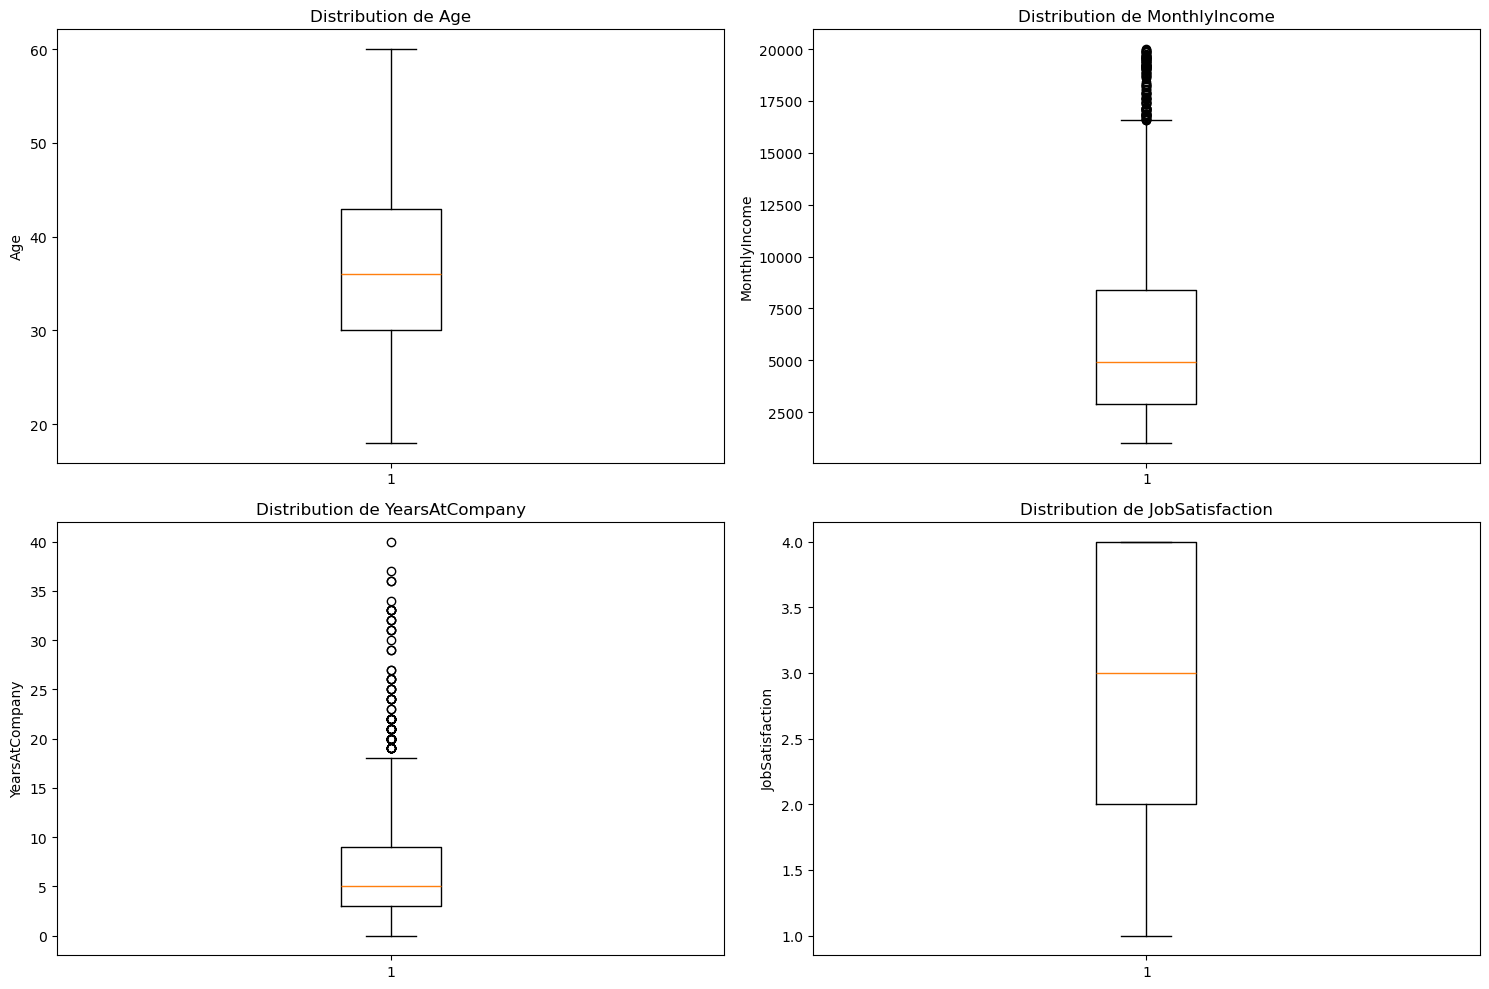

In [15]:
print("\n9. Visualisation des distributions (optionnel):")
key_numeric_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(key_numeric_cols):
    if col in df.columns:
        axes[idx].boxplot(df[col].dropna())
        axes[idx].set_title(f'Distribution de {col}')
        axes[idx].set_ylabel(col)

plt.tight_layout()
plt.savefig('outliers_visualization.png')
print("✓ Graphique sauvegardé: outliers_visualization.png")

In [16]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Configuration pour de meilleurs graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 60)
print("DATA UNDERSTANDING & ANALYSE EN COMPOSANTES PRINCIPALES (ACP)")
print("=" * 60)
print("\n" + "=" * 60)
print("PARTIE 1: DATA UNDERSTANDING")
print("=" * 60)

DATA UNDERSTANDING & ANALYSE EN COMPOSANTES PRINCIPALES (ACP)

PARTIE 1: DATA UNDERSTANDING


In [17]:
# 1. Distribution de la variable cible (Attrition)
print("\n1. Distribution de la variable cible (Attrition):")
attrition_counts = df_cleaned['Attrition'].value_counts()
attrition_pct = df_cleaned['Attrition'].value_counts(normalize=True) * 100
print(attrition_counts)
print(f"\nPourcentages:")
print(f"No: {attrition_pct['No']:.2f}%")
print(f"Yes: {attrition_pct['Yes']:.2f}%")


1. Distribution de la variable cible (Attrition):
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Pourcentages:
No: 83.88%
Yes: 16.12%


✓ Graphique sauvegardé: attrition_distribution.png


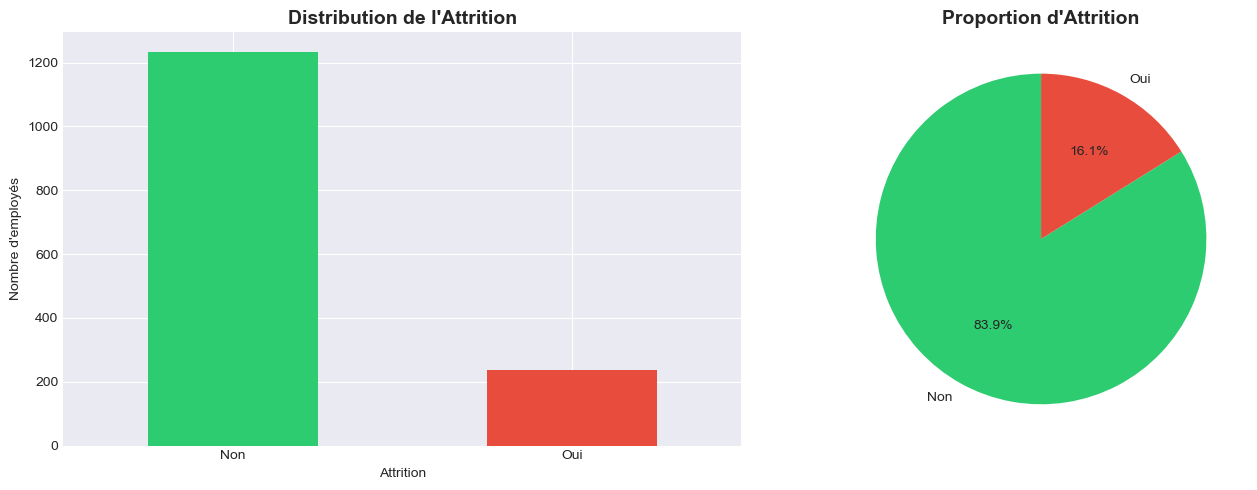

In [18]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
attrition_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution de l\'Attrition', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Nombre d\'employés')
axes[0].set_xticklabels(['Non', 'Oui'], rotation=0)

axes[1].pie(attrition_counts, labels=['Non', 'Oui'], autopct='%1.1f%%', 
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proportion d\'Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('attrition_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Graphique sauvegardé: attrition_distribution.png")


In [19]:
# 2. Analyse des variables numériques
print("\n2. Analyse des variables numériques:")
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()


2. Analyse des variables numériques:


In [20]:
# Exclure les colonnes non pertinentes
exclude_cols = ['EmployeeCount', 'StandardHours', 'EmployeeNumber', 'Over18']
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

print(f"Nombre de variables numériques: {len(numeric_cols)}")
print(f"Variables: {numeric_cols}")

Nombre de variables numériques: 23
Variables: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [21]:
# Corrélation avec Attrition
df_temp = df_cleaned.copy()
df_temp['Attrition_Numeric'] = (df_temp['Attrition'] == 'Yes').astype(int)

correlations = df_temp[numeric_cols + ['Attrition_Numeric']].corr()['Attrition_Numeric'].sort_values(ascending=False)
print("\nTop 10 corrélations avec Attrition:")
print(correlations[1:11])


Top 10 corrélations avec Attrition:
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
Name: Attrition_Numeric, dtype: float64


In [22]:
# 3. Analyse des variables catégorielles
print("\n3. Analyse des variables catégorielles:")
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('Attrition')
print(f"Nombre de variables catégorielles: {len(categorical_cols)}")
print(f"Variables: {categorical_cols}")



3. Analyse des variables catégorielles:
Nombre de variables catégorielles: 8
Variables: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


✓ Graphique sauvegardé: categorical_analysis.png


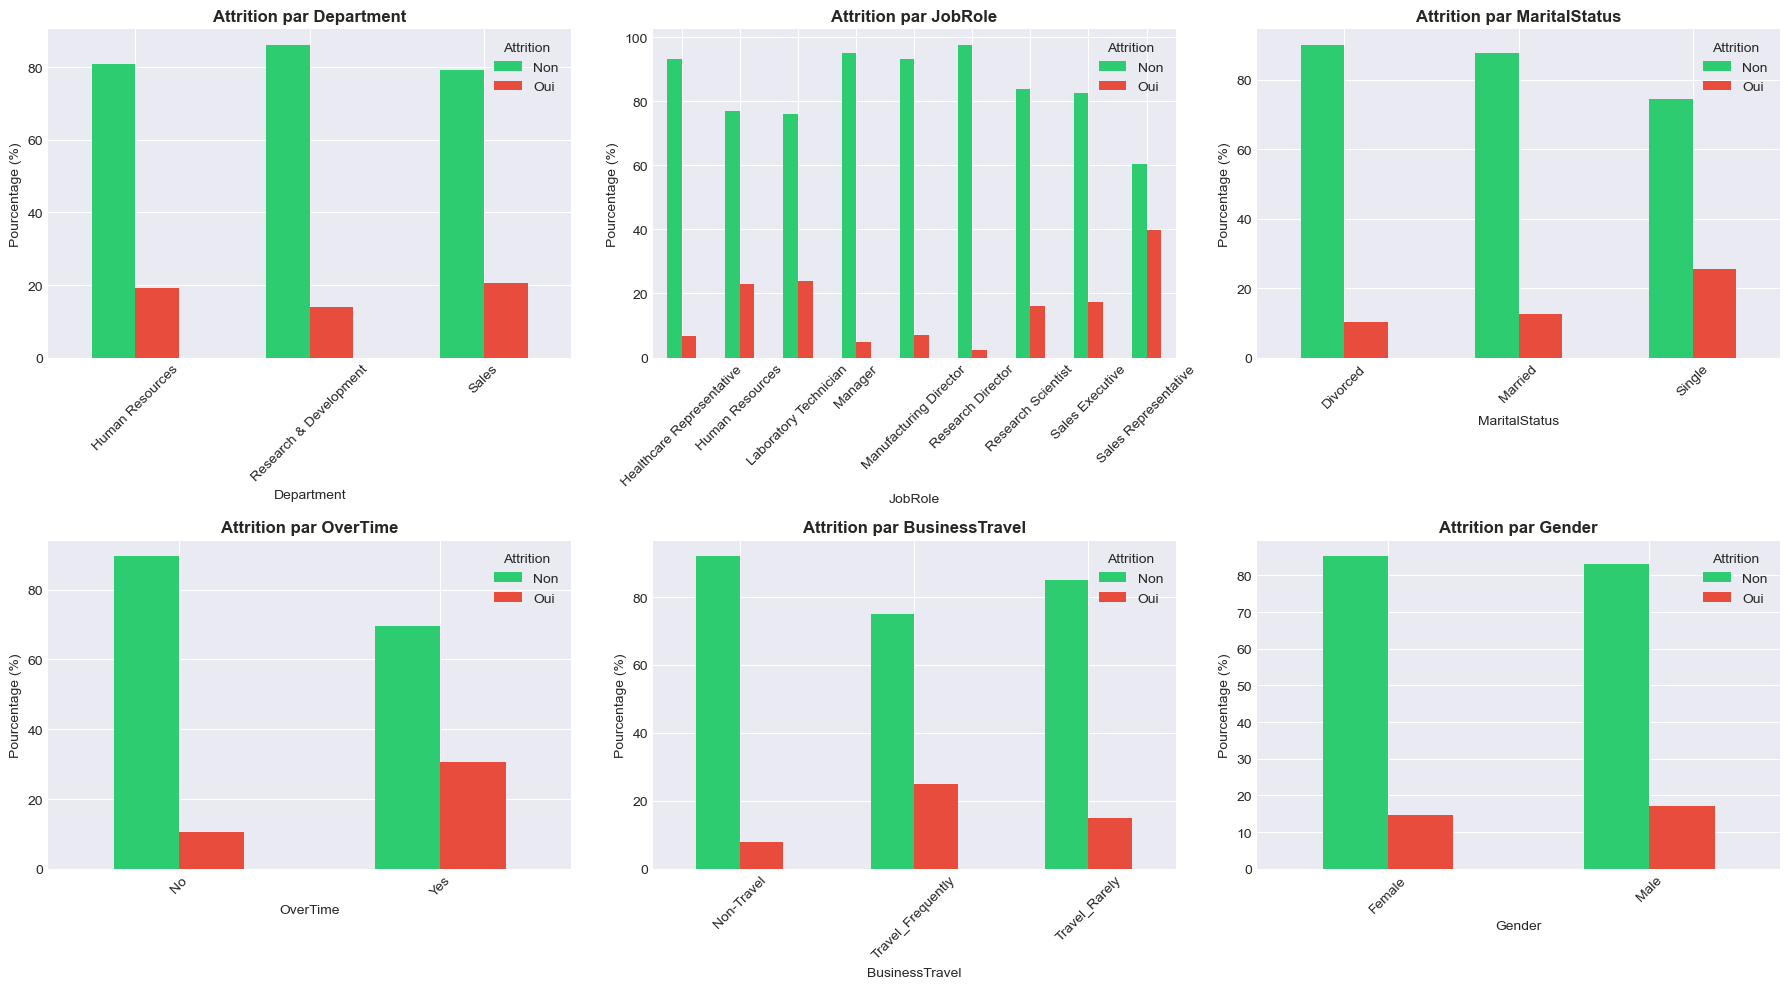

In [23]:
# Visualisation de quelques variables catégorielles importantes
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

important_cat_cols = ['Department', 'JobRole', 'MaritalStatus', 'OverTime', 'BusinessTravel', 'Gender']

for idx, col in enumerate(important_cat_cols[:6]):
    if col in df_cleaned.columns:
        attrition_by_cat = pd.crosstab(df_cleaned[col], df_cleaned['Attrition'], normalize='index') * 100
        attrition_by_cat.plot(kind='bar', ax=axes[idx], stacked=False, color=['#2ecc71', '#e74c3c'])
        axes[idx].set_title(f'Attrition par {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Pourcentage (%)')
        axes[idx].legend(['Non', 'Oui'], title='Attrition')
        axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('categorical_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Graphique sauvegardé: categorical_analysis.png")



4. Matrice de corrélation des variables numériques:
✓ Graphique sauvegardé: correlation_matrix.png


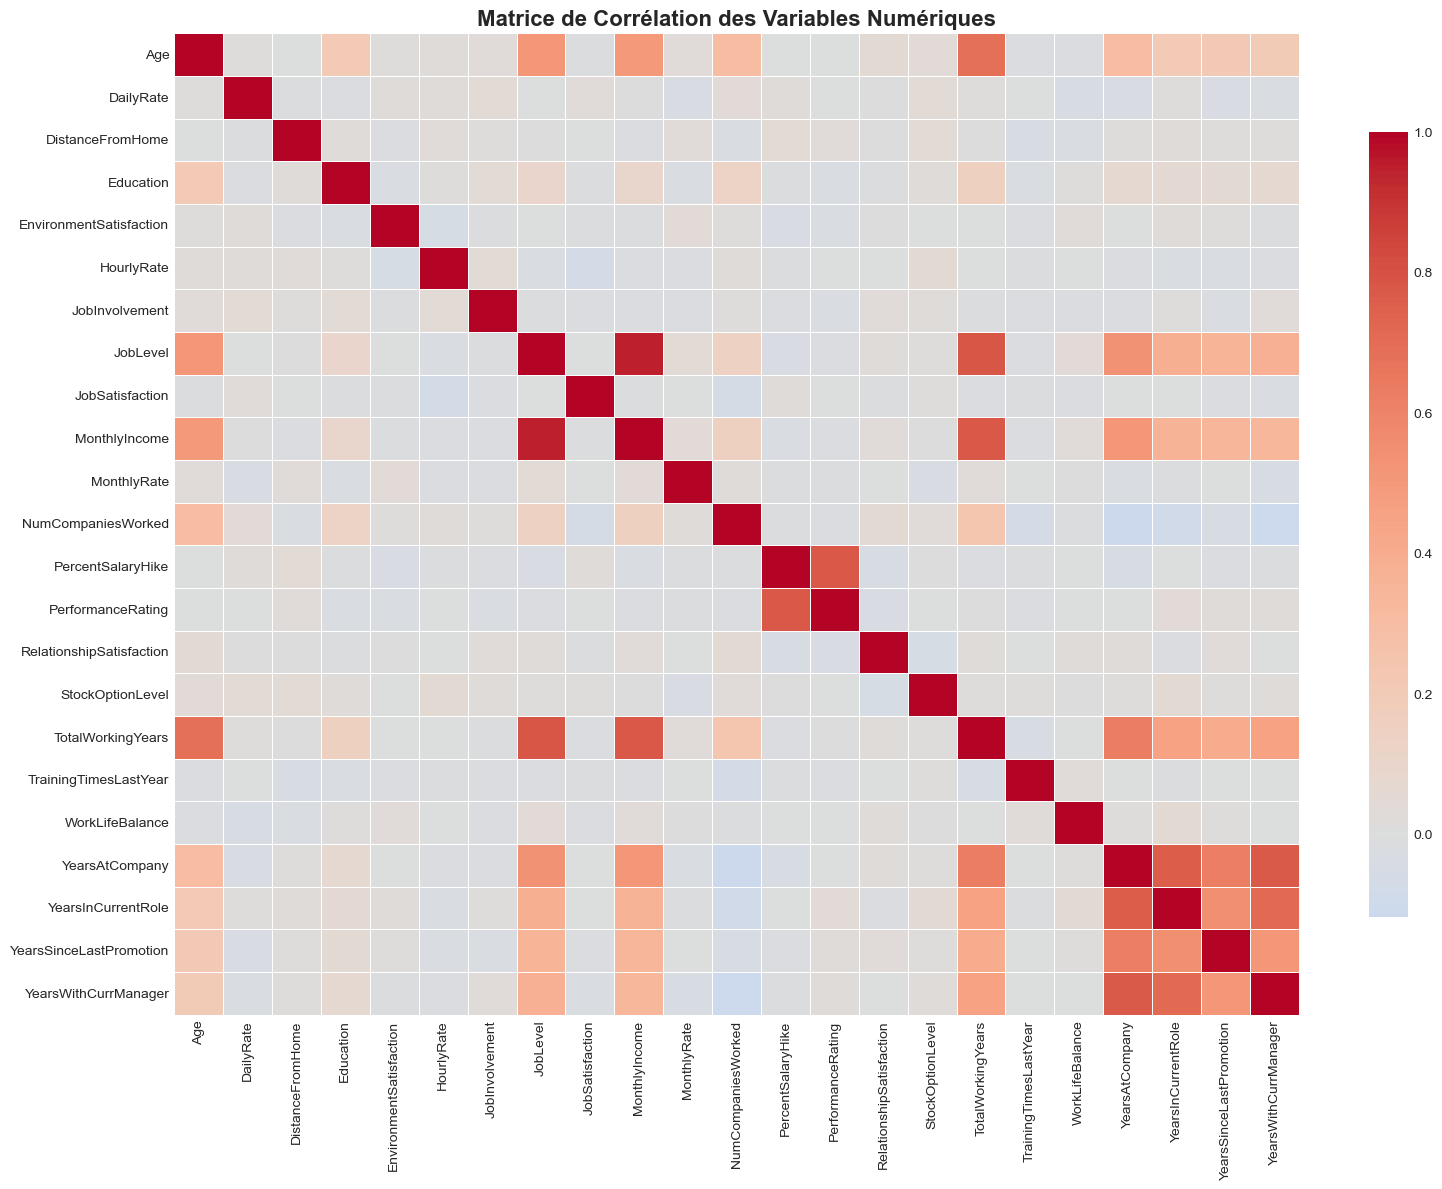

In [24]:
# 4. Matrice de corrélation
print("\n4. Matrice de corrélation des variables numériques:")
plt.figure(figsize=(16, 12))
correlation_matrix = df_cleaned[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matrice de Corrélation des Variables Numériques', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Graphique sauvegardé: correlation_matrix.png")



5. Distribution des variables numériques clés:
✓ Graphique sauvegardé: numeric_distributions.png


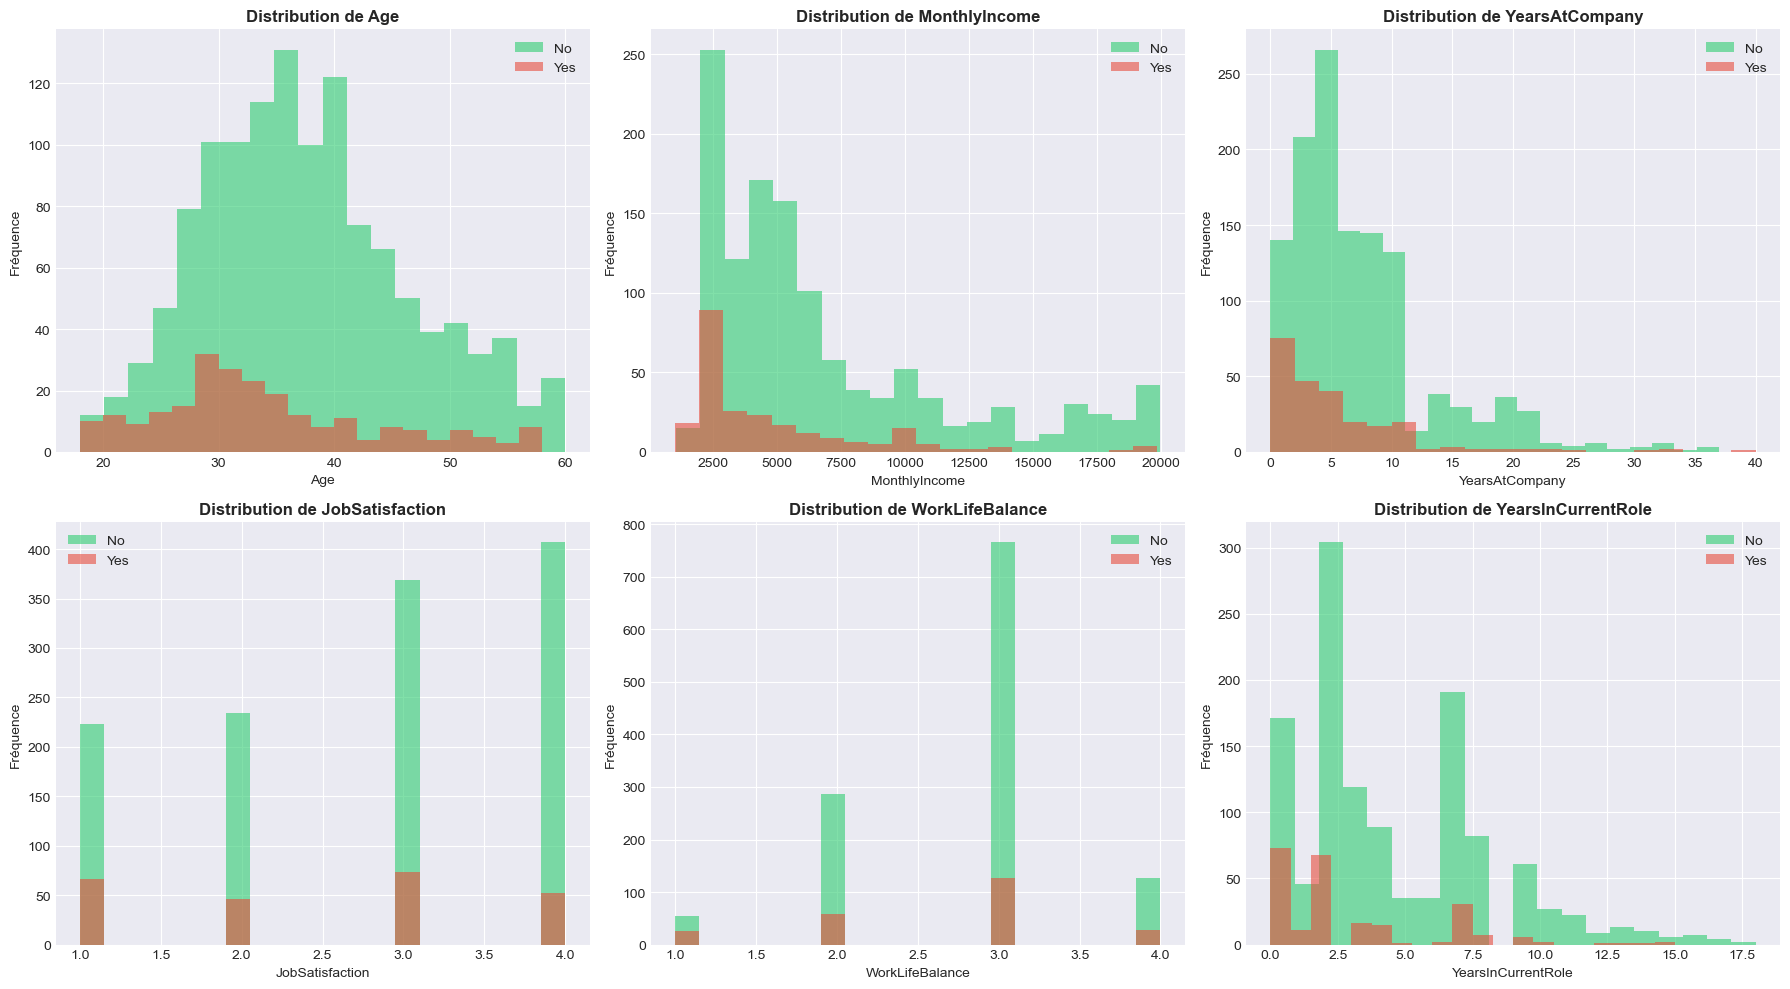

In [25]:
# 5. Distribution des variables numériques clés
print("\n5. Distribution des variables numériques clés:")
key_numeric = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction', 
               'WorkLifeBalance', 'YearsInCurrentRole']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(key_numeric):
    if col in df_cleaned.columns:
        df_cleaned[df_cleaned['Attrition'] == 'No'][col].hist(ax=axes[idx], bins=20, 
                                                                alpha=0.6, label='No', color='#2ecc71')
        df_cleaned[df_cleaned['Attrition'] == 'Yes'][col].hist(ax=axes[idx], bins=20, 
                                                                 alpha=0.6, label='Yes', color='#e74c3c')
        axes[idx].set_title(f'Distribution de {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Fréquence')
        axes[idx].legend()

plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=300, bbox_inches='tight')
print("✓ Graphique sauvegardé: numeric_distributions.png")


In [26]:
print("\n" + "=" * 60)
print("PARTIE 2: ANALYSE EN COMPOSANTES PRINCIPALES (ACP)")
print("=" * 60)
print("\n1. Préparation des données pour l'ACP:")



PARTIE 2: ANALYSE EN COMPOSANTES PRINCIPALES (ACP)

1. Préparation des données pour l'ACP:


In [27]:
# Encoder les variables catégorielles
df_pca = df_cleaned.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_pca[col] = le.fit_transform(df_pca[col])
    label_encoders[col] = le


In [28]:
df_pca['Attrition'] = (df_pca['Attrition'] == 'Yes').astype(int)


In [29]:
# Sélectionner les features pour l'ACP (exclure les colonnes non pertinentes)
features_for_pca = [col for col in df_pca.columns if col not in exclude_cols + ['Attrition']]
X = df_pca[features_for_pca]

print(f"Nombre de features pour l'ACP: {X.shape[1]}")
print(f"Nombre d'observations: {X.shape[0]}")

# 2. Standardisation des données
print("\n2. Standardisation des données:")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("✓ Données standardisées (moyenne=0, écart-type=1)")


Nombre de features pour l'ACP: 30
Nombre d'observations: 1470

2. Standardisation des données:
✓ Données standardisées (moyenne=0, écart-type=1)


In [30]:
# 3. Application de l'ACP
print("\n3. Application de l'ACP:")
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Variance expliquée
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Variance expliquée par les 5 premières composantes:")
for i in range(min(5, len(explained_variance))):
    print(f"  PC{i+1}: {explained_variance[i]*100:.2f}% (Cumulée: {cumulative_variance[i]*100:.2f}%)")



3. Application de l'ACP:
Variance expliquée par les 5 premières composantes:
  PC1: 15.62% (Cumulée: 15.62%)
  PC2: 6.32% (Cumulée: 21.94%)
  PC3: 6.01% (Cumulée: 27.95%)
  PC4: 5.63% (Cumulée: 33.58%)
  PC5: 5.32% (Cumulée: 38.90%)



4. Visualisation de la variance expliquée:
✓ Graphique sauvegardé: pca_variance.png


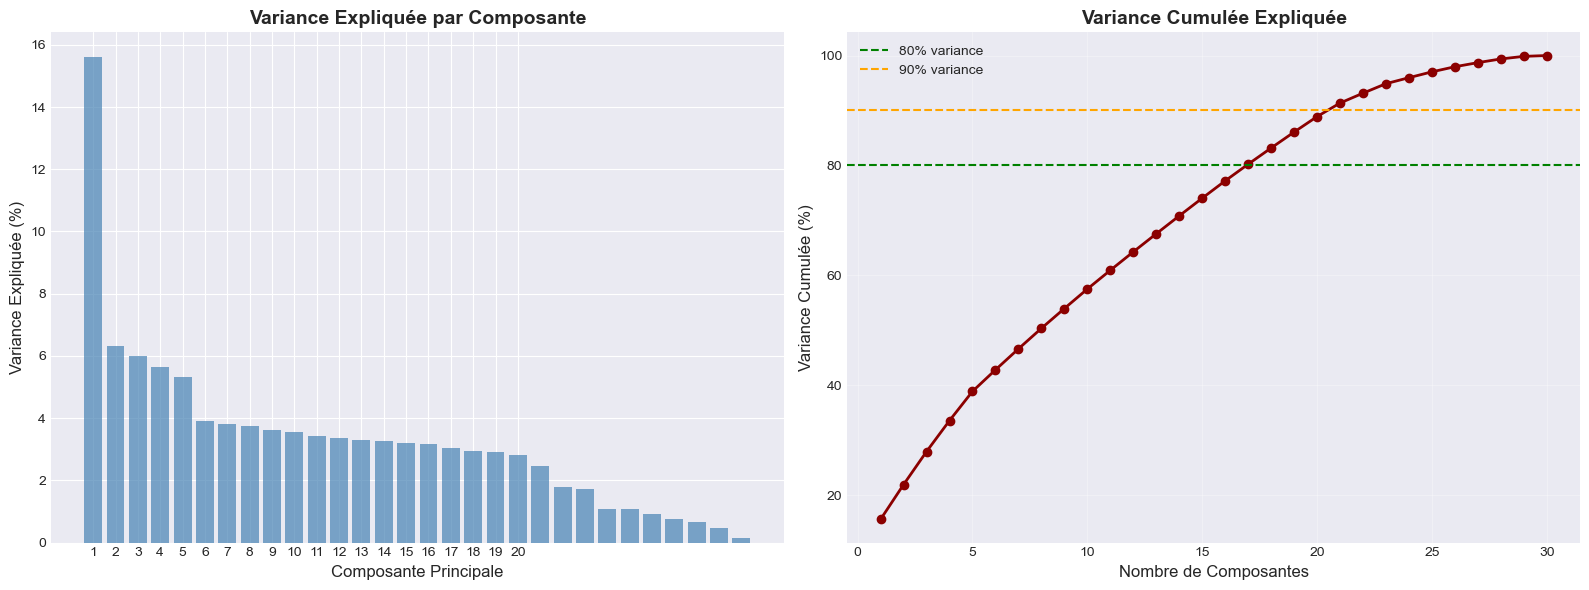

In [31]:
# 4. Visualisation de la variance expliquée
print("\n4. Visualisation de la variance expliquée:")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Variance expliquée par composante
axes[0].bar(range(1, len(explained_variance)+1), explained_variance*100, 
            color='steelblue', alpha=0.7)
axes[0].set_xlabel('Composante Principale', fontsize=12)
axes[0].set_ylabel('Variance Expliquée (%)', fontsize=12)
axes[0].set_title('Variance Expliquée par Composante', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(1, min(21, len(explained_variance)+1)))

# Variance cumulée
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance*100, 
             marker='o', linestyle='-', color='darkred', linewidth=2)
axes[1].axhline(y=80, color='green', linestyle='--', label='80% variance')
axes[1].axhline(y=90, color='orange', linestyle='--', label='90% variance')
axes[1].set_xlabel('Nombre de Composantes', fontsize=12)
axes[1].set_ylabel('Variance Cumulée (%)', fontsize=12)
axes[1].set_title('Variance Cumulée Expliquée', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=300, bbox_inches='tight')
print("✓ Graphique sauvegardé: pca_variance.png")


In [32]:
# 5. Nombre optimal de composantes
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"\n5. Nombre de composantes recommandées:")
print(f"  Pour 80% de variance: {n_components_80} composantes")
print(f"  Pour 90% de variance: {n_components_90} composantes")



5. Nombre de composantes recommandées:
  Pour 80% de variance: 17 composantes
  Pour 90% de variance: 21 composantes



6. Projection sur les 2 premières composantes principales:
✓ Graphique sauvegardé: pca_2d_projection.png


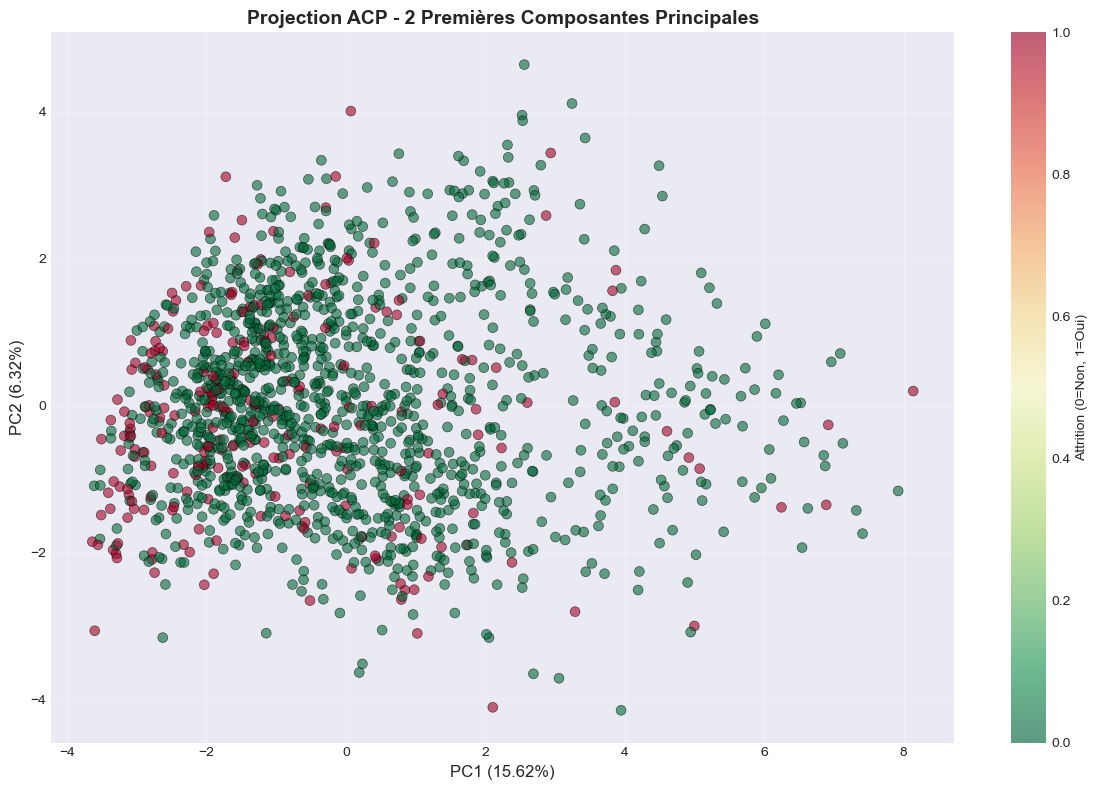

In [33]:
# 6. Projection sur les 2 premières composantes principales
print("\n6. Projection sur les 2 premières composantes principales:")
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                     c=df_pca['Attrition'], cmap='RdYlGn_r', 
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
plt.title('Projection ACP - 2 Premières Composantes Principales', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Attrition (0=Non, 1=Oui)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_2d_projection.png', dpi=300, bbox_inches='tight')
print("✓ Graphique sauvegardé: pca_2d_projection.png")



7. Contribution des variables aux composantes principales:

Top 10 contributions à PC1:
TotalWorkingYears          0.402626
YearsAtCompany             0.389096
JobLevel                   0.381727
MonthlyIncome              0.373633
YearsInCurrentRole         0.333633
YearsWithCurrManager       0.327764
YearsSinceLastPromotion    0.295110
Age                        0.277663
Education                  0.077416
JobRole                    0.061504
Name: PC1, dtype: float64

Top 10 contributions à PC2:
NumCompaniesWorked         0.400819
JobRole                    0.332585
Department                 0.316809
Age                        0.316404
YearsWithCurrManager       0.292534
YearsInCurrentRole         0.288667
MaritalStatus              0.232259
YearsAtCompany             0.230965
YearsSinceLastPromotion    0.222129
StockOptionLevel           0.187296
Name: PC2, dtype: float64
✓ Graphique sauvegardé: pca_contributions.png


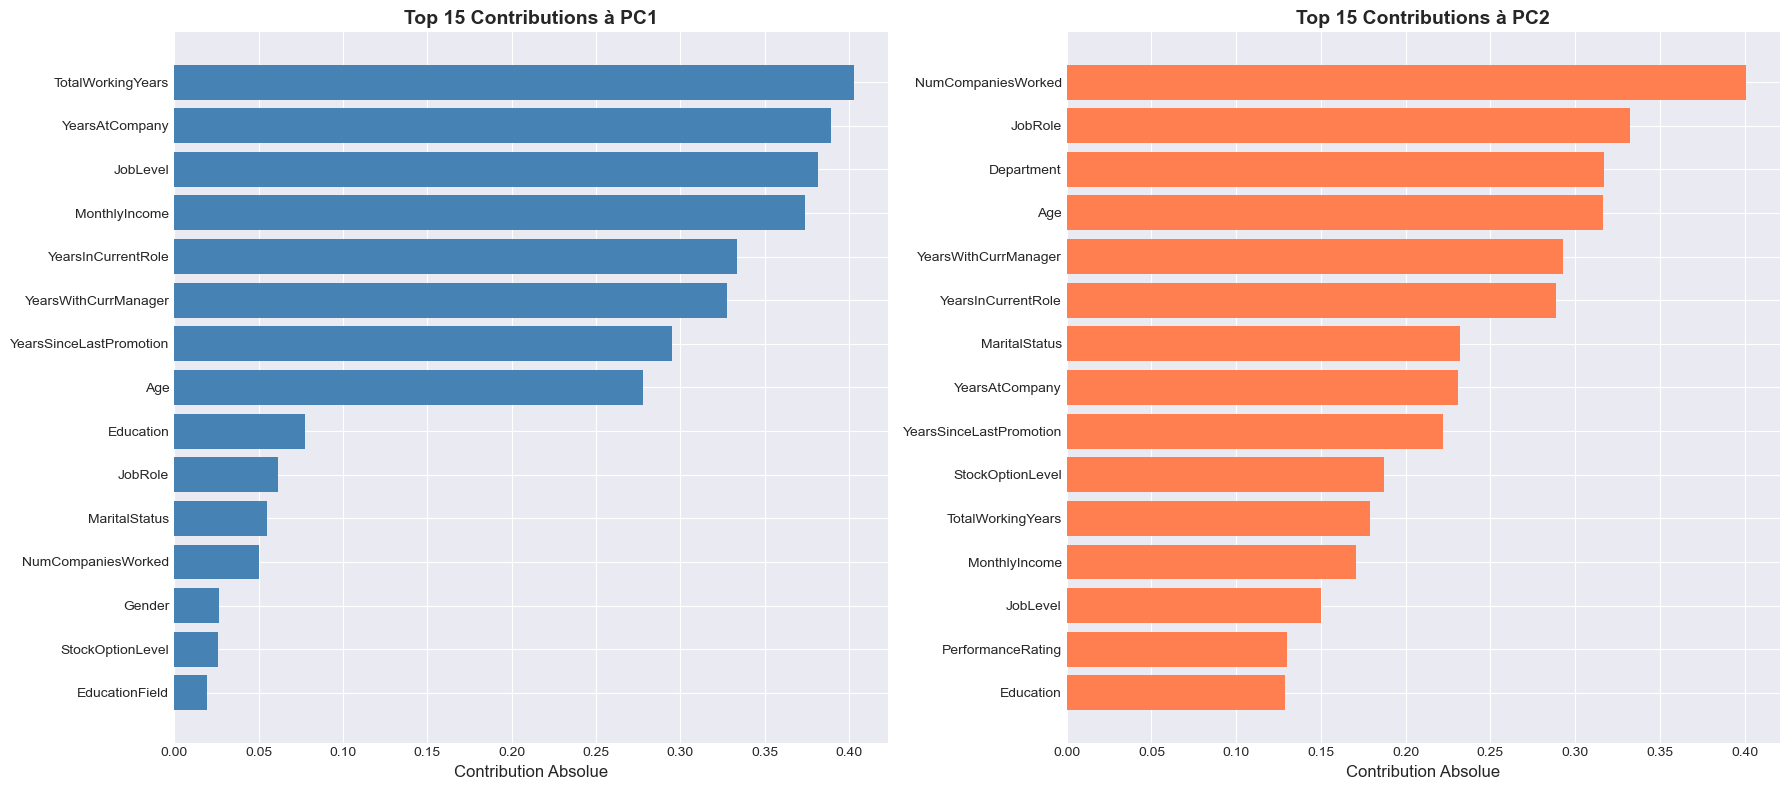

In [34]:
# 7. Contribution des variables aux composantes principales
print("\n7. Contribution des variables aux composantes principales:")
components_df = pd.DataFrame(
    pca.components_[:5].T,
    columns=[f'PC{i+1}' for i in range(5)],
    index=features_for_pca
)

# Top 10 contributions pour PC1 et PC2
print("\nTop 10 contributions à PC1:")
print(components_df['PC1'].abs().sort_values(ascending=False).head(10))

print("\nTop 10 contributions à PC2:")
print(components_df['PC2'].abs().sort_values(ascending=False).head(10))

# Visualisation des contributions
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# PC1
top_pc1 = components_df['PC1'].abs().sort_values(ascending=False).head(15)
axes[0].barh(range(len(top_pc1)), top_pc1.values, color='steelblue')
axes[0].set_yticks(range(len(top_pc1)))
axes[0].set_yticklabels(top_pc1.index)
axes[0].set_xlabel('Contribution Absolue', fontsize=12)
axes[0].set_title('Top 15 Contributions à PC1', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# PC2
top_pc2 = components_df['PC2'].abs().sort_values(ascending=False).head(15)
axes[1].barh(range(len(top_pc2)), top_pc2.values, color='coral')
axes[1].set_yticks(range(len(top_pc2)))
axes[1].set_yticklabels(top_pc2.index)
axes[1].set_xlabel('Contribution Absolue', fontsize=12)
axes[1].set_title('Top 15 Contributions à PC2', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('pca_contributions.png', dpi=300, bbox_inches='tight')
print("✓ Graphique sauvegardé: pca_contributions.png")


In [35]:
print("\n" + "=" * 60)
print("RÉSUMÉ DE L'ANALYSE")
print("=" * 60)
print(f"\n✓ Data Understanding complété")
print(f"✓ ACP réalisée avec succès")
print(f"✓ {len(explained_variance)} composantes principales créées")
print(f"✓ Variance expliquée par PC1+PC2: {(pca_2d.explained_variance_ratio_.sum())*100:.2f}%")
print(f"✓ Recommandation: Utiliser {n_components_80} composantes pour 80% de variance")
print(f"\n✓ Tous les graphiques ont été sauvegardés!")


RÉSUMÉ DE L'ANALYSE

✓ Data Understanding complété
✓ ACP réalisée avec succès
✓ 30 composantes principales créées
✓ Variance expliquée par PC1+PC2: 21.94%
✓ Recommandation: Utiliser 17 composantes pour 80% de variance

✓ Tous les graphiques ont été sauvegardés!


In [36]:
df_pca_transformed = pd.DataFrame(
    X_pca[:, :n_components_80],
    columns=[f'PC{i+1}' for i in range(n_components_80)]
)
df_pca_transformed['Attrition'] = df_pca['Attrition'].values

print(f"\n✓ Données transformées prêtes pour le clustering et la modélisation!")
print(f"  Dimensions: {df_pca_transformed.shape}")


✓ Données transformées prêtes pour le clustering et la modélisation!
  Dimensions: (1470, 18)


In [37]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [38]:
print("=" * 60)
print("DSO 1: SEGMENTATION DES EMPLOYÉS (CLUSTERING)")
print("=" * 60)

# ============================================================================
# PARTIE 1: PRÉPARATION DES DONNÉES POUR LE CLUSTERING
# ============================================================================

print("\n" + "=" * 60)
print("PARTIE 1: PRÉPARATION DES DONNÉES")
print("=" * 60)

DSO 1: SEGMENTATION DES EMPLOYÉS (CLUSTERING)

PARTIE 1: PRÉPARATION DES DONNÉES


In [39]:

clustering_features = [
    'Age', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction',
    'EnvironmentSatisfaction', 'WorkLifeBalance', 'JobInvolvement',
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
    'NumCompaniesWorked', 'TotalWorkingYears', 'TrainingTimesLastYear',
    'PercentSalaryHike', 'StockOptionLevel'
]

In [40]:
# Vérifier que toutes les colonnes existent
available_features = [col for col in clustering_features if col in df_cleaned.columns]
print(f"\nFeatures utilisées pour le clustering: {len(available_features)}")
print(available_features)


Features utilisées pour le clustering: 15
['Age', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'NumCompaniesWorked', 'TotalWorkingYears', 'TrainingTimesLastYear', 'PercentSalaryHike', 'StockOptionLevel']


In [41]:
# Créer le dataset pour clustering
X_clustering = df_cleaned[available_features].copy()
print(f"\nDimensions du dataset: {X_clustering.shape}")



Dimensions du dataset: (1470, 15)


In [42]:
# Standardisation
scaler_clustering = StandardScaler()
X_scaled_clustering = scaler_clustering.fit_transform(X_clustering)
print("✓ Données standardisées")

✓ Données standardisées


In [43]:
print("\n" + "=" * 60)
print("PARTIE 2: MÉTHODE DU COUDE & SILHOUETTE (K-MEANS)")
print("=" * 60)


PARTIE 2: MÉTHODE DU COUDE & SILHOUETTE (K-MEANS)



1. Calcul de l'inertie pour différentes valeurs de K...


  File "C:\Users\MSI\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\MSI\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\MSI\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\MSI\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


  K=2: Inertie=18128.09, Silhouette=0.190
  K=3: Inertie=16812.09, Silhouette=0.111
  K=4: Inertie=15595.33, Silhouette=0.112
  K=5: Inertie=14894.19, Silhouette=0.103
  K=6: Inertie=14417.98, Silhouette=0.100
  K=7: Inertie=14013.67, Silhouette=0.094
  K=8: Inertie=13688.14, Silhouette=0.086
  K=9: Inertie=13305.42, Silhouette=0.088
  K=10: Inertie=13100.84, Silhouette=0.075


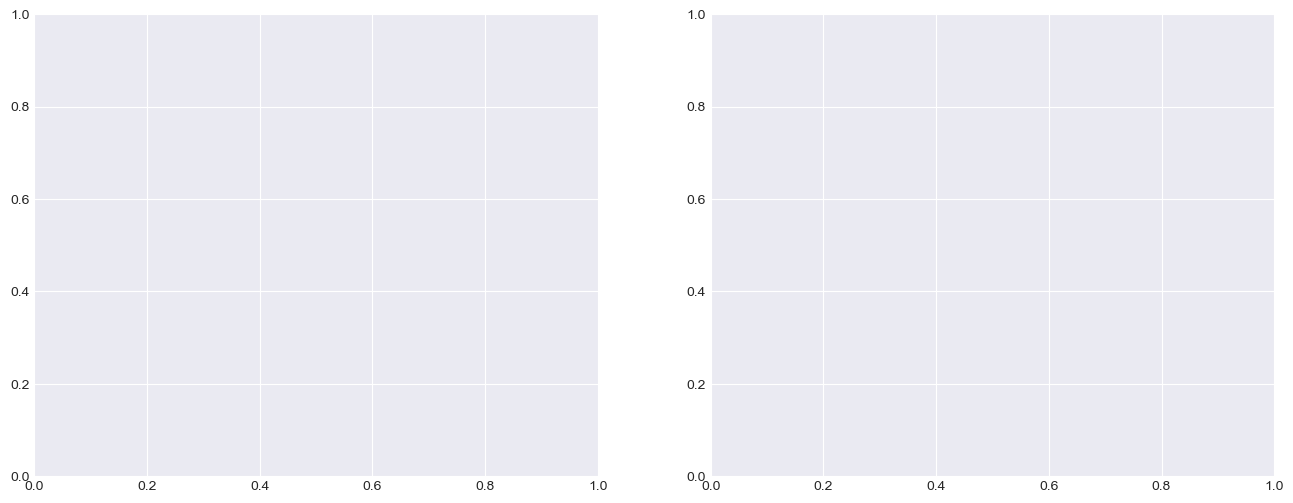

In [44]:
# Méthode du coude (Elbow Method)
print("\n1. Calcul de l'inertie pour différentes valeurs de K...")
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_clustering)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_clustering, kmeans.labels_))
    print(f"  K={k}: Inertie={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.3f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


In [45]:
# Méthode du coude
axes[0].plot(k_range, inertias, marker='o', linestyle='-', linewidth=2, markersize=8, color='steelblue')
axes[0].set_xlabel('Nombre de Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertie (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Méthode du Coude (Elbow Method)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(k_range)

# Score de Silhouette
axes[1].plot(k_range, silhouette_scores, marker='s', linestyle='-', linewidth=2, markersize=8, color='coral')
axes[1].set_xlabel('Nombre de Clusters (K)', fontsize=12)
axes[1].set_ylabel('Score de Silhouette', fontsize=12)
axes[1].set_title('Score de Silhouette par K', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(k_range)

plt.tight_layout()
plt.savefig('kmeans_optimal_k.png', dpi=300, bbox_inches='tight')
print("\n✓ Graphique sauvegardé: kmeans_optimal_k.png")
# Déterminer le K optimal
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\n✓ K optimal suggéré (basé sur Silhouette): {optimal_k}")



✓ Graphique sauvegardé: kmeans_optimal_k.png

✓ K optimal suggéré (basé sur Silhouette): 2


<Figure size 640x480 with 0 Axes>

In [46]:
print("\n" + "=" * 60)
print(f"PARTIE 3: APPLICATION DU K-MEANS (K={optimal_k})")
print("=" * 60)


PARTIE 3: APPLICATION DU K-MEANS (K=2)


In [47]:
# Appliquer K-Means avec le K optimal
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters_kmeans = kmeans_final.fit_predict(X_scaled_clustering)


In [48]:
# Ajouter les clusters au dataframe
df_clustered = df_cleaned.copy()
df_clustered['Cluster_KMeans'] = clusters_kmeans

print(f"\n1. Distribution des clusters K-Means:")
cluster_counts = pd.Series(clusters_kmeans).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    pct = (count / len(clusters_kmeans)) * 100
    print(f"  Cluster {cluster_id}: {count} employés ({pct:.2f}%)")



1. Distribution des clusters K-Means:
  Cluster 0: 487 employés (33.13%)
  Cluster 1: 983 employés (66.87%)


In [49]:
# Métriques de qualité
silhouette_kmeans = silhouette_score(X_scaled_clustering, clusters_kmeans)
davies_bouldin_kmeans = davies_bouldin_score(X_scaled_clustering, clusters_kmeans)
calinski_harabasz_kmeans = calinski_harabasz_score(X_scaled_clustering, clusters_kmeans)

print(f"\n2. Métriques de qualité K-Means:")
print(f"  Silhouette Score: {silhouette_kmeans:.3f} (plus proche de 1 = meilleur)")
print(f"  Davies-Bouldin Index: {davies_bouldin_kmeans:.3f} (plus bas = meilleur)")
print(f"  Calinski-Harabasz Score: {calinski_harabasz_kmeans:.2f} (plus haut = meilleur)")



2. Métriques de qualité K-Means:
  Silhouette Score: 0.190 (plus proche de 1 = meilleur)
  Davies-Bouldin Index: 2.032 (plus bas = meilleur)
  Calinski-Harabasz Score: 317.60 (plus haut = meilleur)


In [50]:
print("\n" + "=" * 60)
print("PARTIE 4: PROFIL DES CLUSTERS K-MEANS")
print("=" * 60)


PARTIE 4: PROFIL DES CLUSTERS K-MEANS


In [51]:
print("\n1. Caractéristiques moyennes par cluster:")
cluster_profiles = df_clustered.groupby('Cluster_KMeans')[available_features].mean()
print(cluster_profiles.round(2))



1. Caractéristiques moyennes par cluster:
                  Age  MonthlyIncome  YearsAtCompany  JobSatisfaction  \
Cluster_KMeans                                                          
0               41.97       10323.43           13.01             2.74   
1               34.43        4610.17            4.04             2.72   

                EnvironmentSatisfaction  WorkLifeBalance  JobInvolvement  \
Cluster_KMeans                                                             
0                                  2.78             2.79            2.75   
1                                  2.69             2.75            2.72   

                YearsInCurrentRole  YearsSinceLastPromotion  \
Cluster_KMeans                                                
0                             7.88                     4.87   
1                             2.42                     0.86   

                YearsWithCurrManager  NumCompaniesWorked  TotalWorkingYears  \
Cluster_KMeans             


2. Taux d'attrition par cluster:
  Cluster 0: 9.45%
  Cluster 1: 19.43%

✓ Graphique sauvegardé: kmeans_cluster_profiles.png


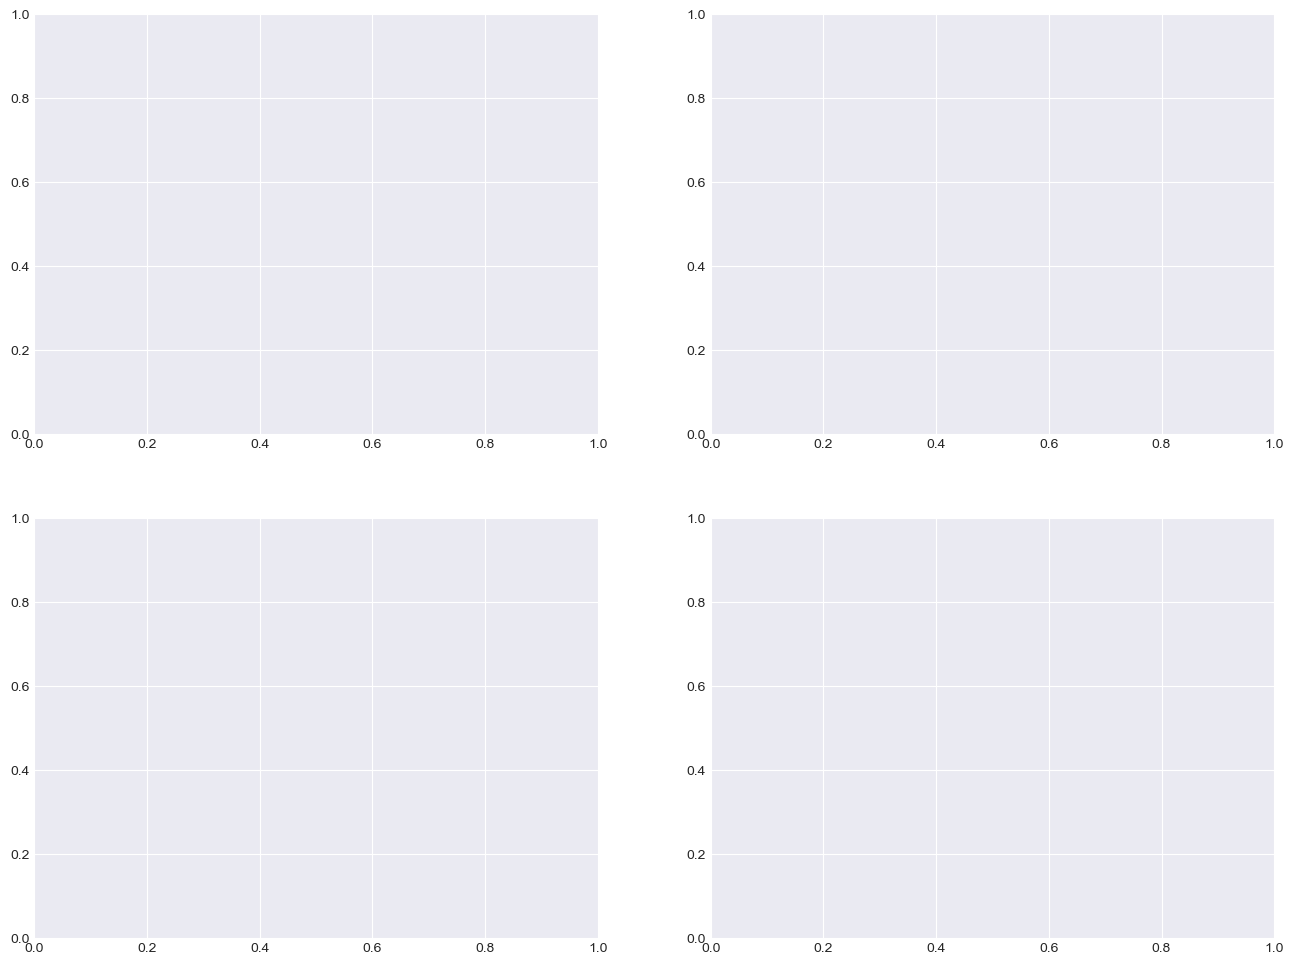

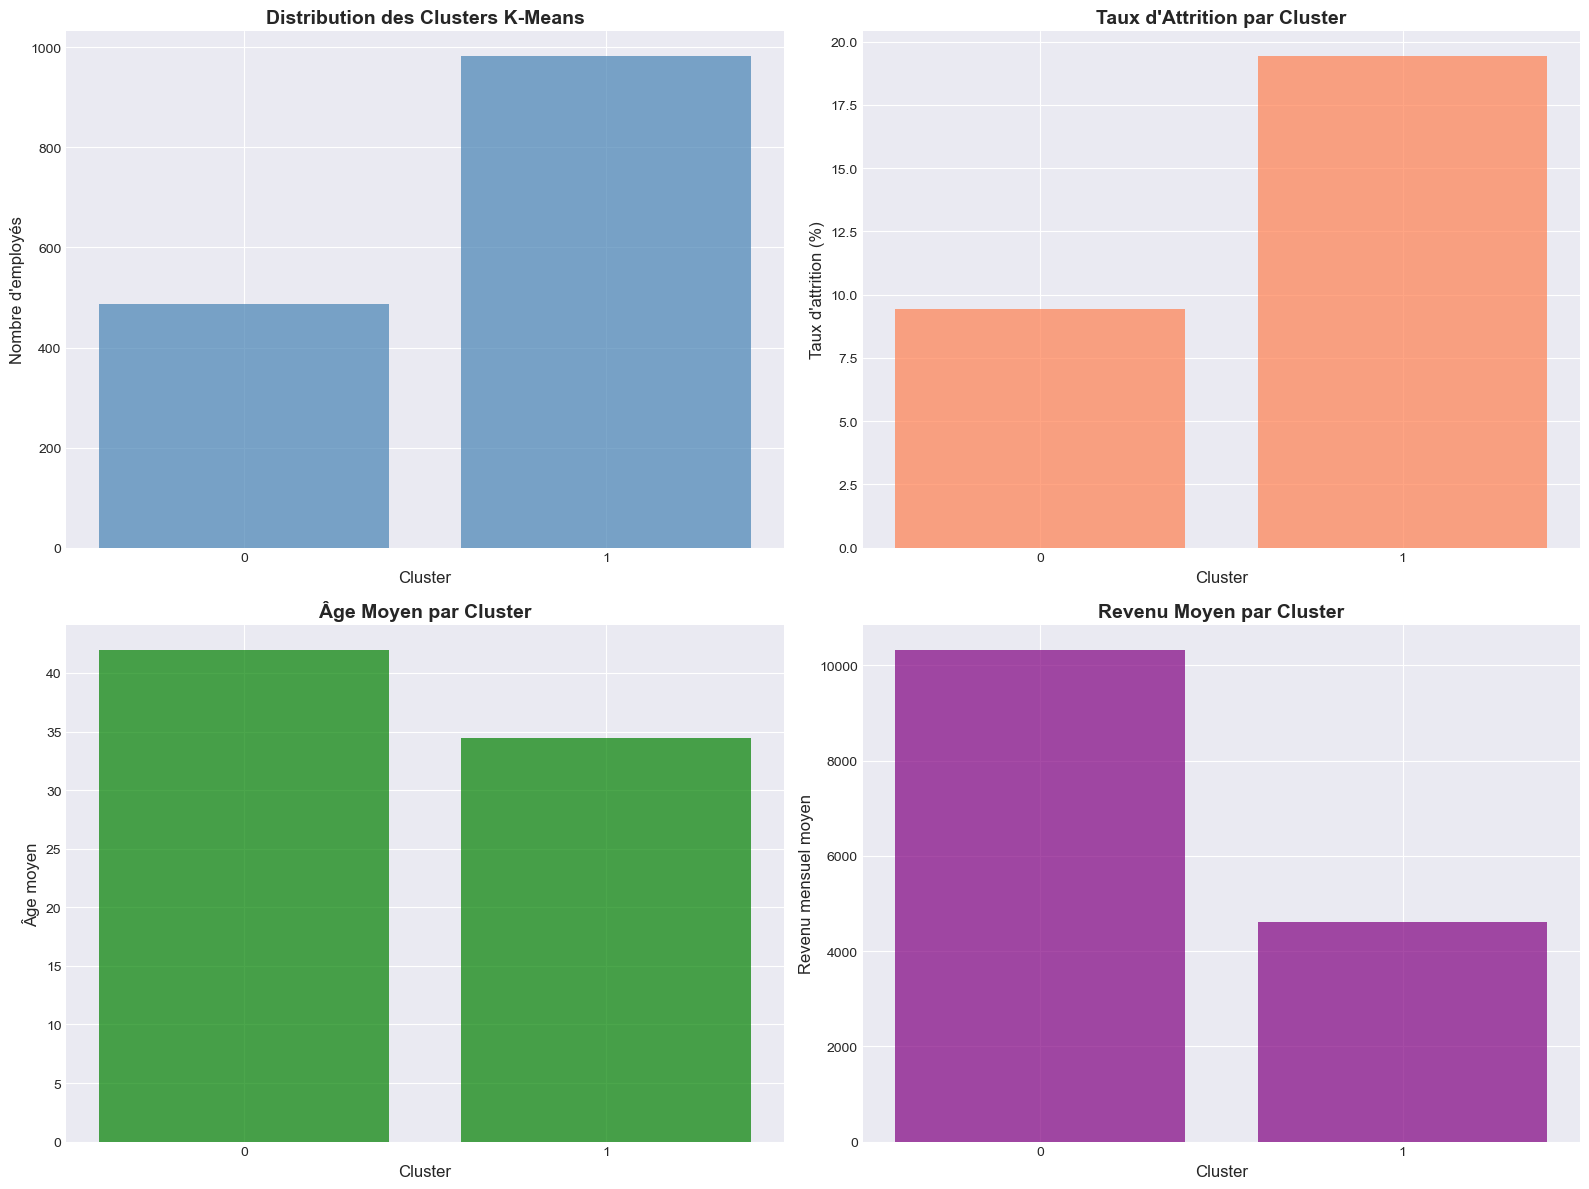

In [52]:
# Taux d'attrition par cluster
print("\n2. Taux d'attrition par cluster:")
attrition_by_cluster = df_clustered.groupby('Cluster_KMeans')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)
for cluster_id, rate in attrition_by_cluster.items():
    print(f"  Cluster {cluster_id}: {rate:.2f}%")

# Visualisation des profils
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# Visualisation des profils
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribution des clusters
axes[0, 0].bar(cluster_counts.index, cluster_counts.values, color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Cluster', fontsize=12)
axes[0, 0].set_ylabel('Nombre d\'employés', fontsize=12)
axes[0, 0].set_title('Distribution des Clusters K-Means', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(cluster_counts.index)

# Taux d'attrition par cluster
axes[0, 1].bar(attrition_by_cluster.index, attrition_by_cluster.values, color='coral', alpha=0.7)
axes[0, 1].set_xlabel('Cluster', fontsize=12)
axes[0, 1].set_ylabel('Taux d\'attrition (%)', fontsize=12)
axes[0, 1].set_title('Taux d\'Attrition par Cluster', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(attrition_by_cluster.index)

# Âge moyen par cluster
age_by_cluster = df_clustered.groupby('Cluster_KMeans')['Age'].mean()
axes[1, 0].bar(age_by_cluster.index, age_by_cluster.values, color='green', alpha=0.7)
axes[1, 0].set_xlabel('Cluster', fontsize=12)
axes[1, 0].set_ylabel('Âge moyen', fontsize=12)
axes[1, 0].set_title('Âge Moyen par Cluster', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(age_by_cluster.index)

# Revenu moyen par cluster
income_by_cluster = df_clustered.groupby('Cluster_KMeans')['MonthlyIncome'].mean()
axes[1, 1].bar(income_by_cluster.index, income_by_cluster.values, color='purple', alpha=0.7)
axes[1, 1].set_xlabel('Cluster', fontsize=12)
axes[1, 1].set_ylabel('Revenu mensuel moyen', fontsize=12)
axes[1, 1].set_title('Revenu Moyen par Cluster', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(income_by_cluster.index)

plt.tight_layout()
plt.savefig('kmeans_cluster_profiles.png', dpi=300, bbox_inches='tight')
print("\n✓ Graphique sauvegardé: kmeans_cluster_profiles.png")



In [53]:

print("\n" + "=" * 60)
print("PARTIE 5: VISUALISATION 2D DES CLUSTERS")
print("=" * 60)


PARTIE 5: VISUALISATION 2D DES CLUSTERS


In [54]:
from sklearn.decomposition import PCA


In [55]:
# Réduire à 2 dimensions avec ACP
pca_viz = PCA(n_components=2)
X_pca_viz = pca_viz.fit_transform(X_scaled_clustering)

plt.figure(figsize=(14, 10))

<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>

✓ Graphique sauvegardé: kmeans_2d_visualization.png


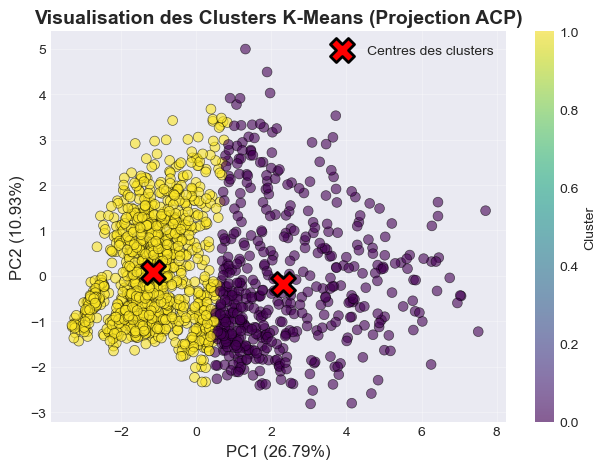

In [56]:
# K-Means
scatter = plt.scatter(X_pca_viz[:, 0], X_pca_viz[:, 1], 
                     c=clusters_kmeans, cmap='viridis', 
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

# Centres des clusters
centers_pca = pca_viz.transform(kmeans_final.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], 
           c='red', marker='X', s=300, edgecolors='black', linewidth=2,
           label='Centres des clusters')

plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
plt.title('Visualisation des Clusters K-Means (Projection ACP)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_2d_visualization.png', dpi=300, bbox_inches='tight')
print("✓ Graphique sauvegardé: kmeans_2d_visualization.png")



In [57]:
print("\n" + "=" * 60)
print("PARTIE 6: DBSCAN (CLUSTERING BASÉ SUR LA DENSITÉ)")
print("=" * 60)


PARTIE 6: DBSCAN (CLUSTERING BASÉ SUR LA DENSITÉ)


In [58]:
print("\n1. Test de différents paramètres eps pour DBSCAN:")
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5]
dbscan_results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    clusters_dbscan = dbscan.fit_predict(X_scaled_clustering)
    n_clusters = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
    n_noise = list(clusters_dbscan).count(-1)
    
    dbscan_results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': (n_noise / len(clusters_dbscan)) * 100
    })
    
    print(f"  eps={eps}: {n_clusters} clusters, {n_noise} points de bruit ({dbscan_results[-1]['noise_pct']:.2f}%)")



1. Test de différents paramètres eps pour DBSCAN:
  eps=0.5: 0 clusters, 1470 points de bruit (100.00%)
  eps=1.0: 0 clusters, 1470 points de bruit (100.00%)
  eps=1.5: 5 clusters, 1432 points de bruit (97.41%)
  eps=2.0: 5 clusters, 1013 points de bruit (68.91%)
  eps=2.5: 2 clusters, 407 points de bruit (27.69%)



2. DBSCAN final (eps=1.5):
  Nombre de clusters: 5
  Points de bruit: 1432 (97.41%)
✓ Graphique sauvegardé: dbscan_visualization.png


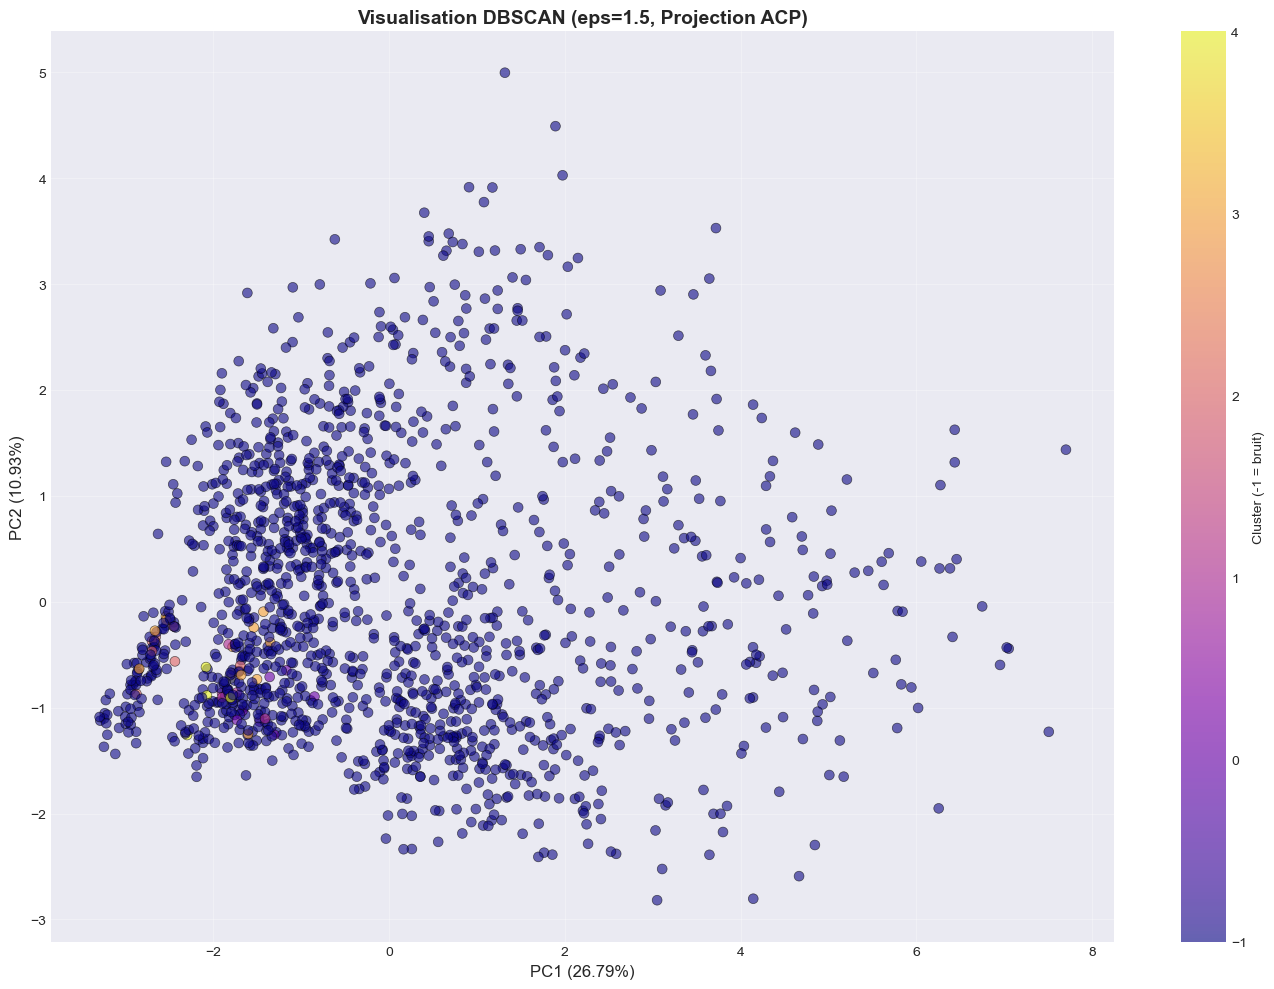

In [59]:
# Choisir le meilleur eps (celui avec le moins de bruit et un nombre raisonnable de clusters)
best_eps = 1.5  # Vous pouvez ajuster selon les résultats
dbscan_final = DBSCAN(eps=best_eps, min_samples=5)
clusters_dbscan_final = dbscan_final.fit_predict(X_scaled_clustering)

df_clustered['Cluster_DBSCAN'] = clusters_dbscan_final

n_clusters_dbscan = len(set(clusters_dbscan_final)) - (1 if -1 in clusters_dbscan_final else 0)
n_noise_dbscan = list(clusters_dbscan_final).count(-1)

print(f"\n2. DBSCAN final (eps={best_eps}):")
print(f"  Nombre de clusters: {n_clusters_dbscan}")
print(f"  Points de bruit: {n_noise_dbscan} ({(n_noise_dbscan/len(clusters_dbscan_final))*100:.2f}%)")

# Visualisation DBSCAN
plt.figure(figsize=(14, 10))
scatter = plt.scatter(X_pca_viz[:, 0], X_pca_viz[:, 1], 
                     c=clusters_dbscan_final, cmap='plasma', 
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
plt.title(f'Visualisation DBSCAN (eps={best_eps}, Projection ACP)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster (-1 = bruit)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_visualization.png', dpi=300, bbox_inches='tight')
print("✓ Graphique sauvegardé: dbscan_visualization.png")



In [60]:
print("\n" + "=" * 60)
print("PARTIE 7: INTERPRÉTATION DES SEGMENTS K-MEANS")
print("=" * 60)


PARTIE 7: INTERPRÉTATION DES SEGMENTS K-MEANS


In [61]:
print("\n1. Profil détaillé de chaque segment:")
for cluster_id in sorted(df_clustered['Cluster_KMeans'].unique()):
    cluster_data = df_clustered[df_clustered['Cluster_KMeans'] == cluster_id]
    
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster_id} - {len(cluster_data)} employés ({len(cluster_data)/len(df_clustered)*100:.1f}%)")
    print(f"{'='*50}")
    
    print(f"  Âge moyen: {cluster_data['Age'].mean():.1f} ans")
    print(f"  Revenu mensuel moyen: {cluster_data['MonthlyIncome'].mean():.0f}")
    print(f"  Années dans l'entreprise: {cluster_data['YearsAtCompany'].mean():.1f}")
    print(f"  Satisfaction au travail: {cluster_data['JobSatisfaction'].mean():.2f}/4")
    print(f"  Équilibre vie-travail: {cluster_data['WorkLifeBalance'].mean():.2f}/4")
    print(f"  Taux d'attrition: {(cluster_data['Attrition']=='Yes').sum()/len(cluster_data)*100:.1f}%")
    
    # Caractéristiques dominantes
    if cluster_data['MonthlyIncome'].mean() > df_clustered['MonthlyIncome'].mean():
        print(f"  → Revenu supérieur à la moyenne")
    if cluster_data['Age'].mean() > df_clustered['Age'].mean():
        print(f"  → Employés plus âgés que la moyenne")
    if (cluster_data['Attrition']=='Yes').sum()/len(cluster_data) > (df_clustered['Attrition']=='Yes').sum()/len(df_clustered):
        print(f"  ⚠️ RISQUE D'ATTRITION ÉLEVÉ")



1. Profil détaillé de chaque segment:

CLUSTER 0 - 487 employés (33.1%)
  Âge moyen: 42.0 ans
  Revenu mensuel moyen: 10323
  Années dans l'entreprise: 13.0
  Satisfaction au travail: 2.74/4
  Équilibre vie-travail: 2.79/4
  Taux d'attrition: 9.4%
  → Revenu supérieur à la moyenne
  → Employés plus âgés que la moyenne

CLUSTER 1 - 983 employés (66.9%)
  Âge moyen: 34.4 ans
  Revenu mensuel moyen: 4610
  Années dans l'entreprise: 4.0
  Satisfaction au travail: 2.72/4
  Équilibre vie-travail: 2.75/4
  Taux d'attrition: 19.4%
  ⚠️ RISQUE D'ATTRITION ÉLEVÉ


In [62]:
print("\n" + "=" * 60)
print("PARTIE 8: SAUVEGARDE DES RÉSULTATS")
print("=" * 60)


PARTIE 8: SAUVEGARDE DES RÉSULTATS


In [63]:
df_clustered.to_csv('employees_with_clusters.csv', index=False)
print("✓ Dataset avec clusters sauvegardé: employees_with_clusters.csv")


✓ Dataset avec clusters sauvegardé: employees_with_clusters.csv


In [64]:
# Résumé final
print("\n" + "=" * 60)
print("RÉSUMÉ DE LA SEGMENTATION")
print("=" * 60)
print(f"\n✓ K-Means: {optimal_k} segments identifiés")
print(f"✓ Silhouette Score: {silhouette_kmeans:.3f}")
print(f"✓ DBSCAN: {n_clusters_dbscan} clusters + {n_noise_dbscan} points de bruit")
print(f"✓ Tous les graphiques et données sauvegardés")



RÉSUMÉ DE LA SEGMENTATION

✓ K-Means: 2 segments identifiés
✓ Silhouette Score: 0.190
✓ DBSCAN: 5 clusters + 1432 points de bruit
✓ Tous les graphiques et données sauvegardés


In [65]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

In [66]:
print("=" * 60)
print("DSO 2: PRÉDICTION DE L'ATTRITION DES EMPLOYÉS")
print("=" * 60)
print("\n" + "=" * 60)
print("PARTIE 1: PRÉPARATION DES DONNÉES")
print("=" * 60)

DSO 2: PRÉDICTION DE L'ATTRITION DES EMPLOYÉS

PARTIE 1: PRÉPARATION DES DONNÉES


In [67]:
df_model = df_cleaned.copy()


In [68]:
# 1. Encoder la variable cible
print("\n1. Encodage de la variable cible (Attrition):")
df_model['Attrition'] = (df_model['Attrition'] == 'Yes').astype(int)
print(f"  0 = Pas d'attrition, 1 = Attrition")
print(f"  Distribution: {df_model['Attrition'].value_counts().to_dict()}")

# 2. Sélectionner les features pertinentes
print("\n2. Sélection des features pour la prédiction:")


1. Encodage de la variable cible (Attrition):
  0 = Pas d'attrition, 1 = Attrition
  Distribution: {0: 1233, 1: 237}

2. Sélection des features pour la prédiction:


In [69]:
numeric_features = [
    'Age', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction',
    'EnvironmentSatisfaction', 'WorkLifeBalance', 'JobInvolvement',
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
    'NumCompaniesWorked', 'TotalWorkingYears', 'TrainingTimesLastYear',
    'PercentSalaryHike', 'StockOptionLevel', 'DistanceFromHome',
    'JobLevel', 'RelationshipSatisfaction'
]


In [70]:
categorical_features = [
    'BusinessTravel', 'Department', 'EducationField', 'Gender',
    'JobRole', 'MaritalStatus', 'OverTime'
]


In [71]:
# Vérifier les features disponibles
numeric_features = [f for f in numeric_features if f in df_model.columns]
categorical_features = [f for f in categorical_features if f in df_model.columns]

print(f"  Features numériques: {len(numeric_features)}")
print(f"  Features catégorielles: {len(categorical_features)}")


  Features numériques: 18
  Features catégorielles: 7


In [72]:
# 3. Encoder les variables catégorielles
print("\n3. Encodage des variables catégorielles:")
df_encoded = df_model.copy()
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

print(f"  ✓ {len(categorical_features)} variables encodées")



3. Encodage des variables catégorielles:
  ✓ 7 variables encodées


In [73]:
all_features = numeric_features + categorical_features
X = df_encoded[all_features]
y = df_encoded['Attrition']

print(f"\n4. Dataset final:")
print(f"  Nombre de features: {X.shape[1]}")
print(f"  Nombre d'observations: {X.shape[0]}")
print(f"  Classe 0 (No): {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%)")
print(f"  Classe 1 (Yes): {(y==1).sum()} ({(y==1).sum()/len(y)*100:.1f}%)")



4. Dataset final:
  Nombre de features: 25
  Nombre d'observations: 1470
  Classe 0 (No): 1233 (83.9%)
  Classe 1 (Yes): 237 (16.1%)


In [74]:
# 5. Split train/test
print("\n5. Division train/test (80/20):")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"  Train: {X_train.shape[0]} observations")
print(f"  Test: {X_test.shape[0]} observations")



5. Division train/test (80/20):
  Train: 1176 observations
  Test: 294 observations


In [75]:
print("\n6. Standardisation des features:")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("  ✓ Features standardisées")


6. Standardisation des features:
  ✓ Features standardisées


In [76]:
print("\n" + "=" * 60)
print("PARTIE 2: ENTRAÎNEMENT DES MODÈLES")
print("=" * 60)


PARTIE 2: ENTRAÎNEMENT DES MODÈLES


In [77]:
results = {}

In [78]:
# 1. Logistic Regression
print("\n1. Logistic Regression:")
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_pred_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

results['Logistic Regression'] = {
    'model': lr,
    'predictions': y_pred_lr,
    'probabilities': y_pred_proba_lr,
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr),
    'recall': recall_score(y_test, y_pred_lr),
    'f1': f1_score(y_test, y_pred_lr),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_lr)
}
print(f"  ✓ Accuracy: {results['Logistic Regression']['accuracy']:.4f}")
print(f"  ✓ F1-Score: {results['Logistic Regression']['f1']:.4f}")



1. Logistic Regression:
  ✓ Accuracy: 0.8878
  ✓ F1-Score: 0.5600


In [79]:
# 2. Decision Tree
print("\n2. Decision Tree:")
dt = DecisionTreeClassifier(random_state=42, max_depth=10)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_pred_proba_dt = dt.predict_proba(X_test)[:, 1]

results['Decision Tree'] = {
    'model': dt,
    'predictions': y_pred_dt,
    'probabilities': y_pred_proba_dt,
    'accuracy': accuracy_score(y_test, y_pred_dt),
    'precision': precision_score(y_test, y_pred_dt),
    'recall': recall_score(y_test, y_pred_dt),
    'f1': f1_score(y_test, y_pred_dt),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_dt)
}
print(f"  ✓ Accuracy: {results['Decision Tree']['accuracy']:.4f}")
print(f"  ✓ F1-Score: {results['Decision Tree']['f1']:.4f}")



2. Decision Tree:
  ✓ Accuracy: 0.8027
  ✓ F1-Score: 0.3696


In [80]:
# 3. Random Forest
print("\n3. Random Forest:")
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

results['Random Forest'] = {
    'model': rf,
    'predictions': y_pred_rf,
    'probabilities': y_pred_proba_rf,
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'recall': recall_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_rf)
}
print(f"  ✓ Accuracy: {results['Random Forest']['accuracy']:.4f}")
print(f"  ✓ F1-Score: {results['Random Forest']['f1']:.4f}")



3. Random Forest:
  ✓ Accuracy: 0.8299
  ✓ F1-Score: 0.1935


In [81]:
# 4. Gradient Boosting
print("\n4. Gradient Boosting:")
gb = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_pred_proba_gb = gb.predict_proba(X_test)[:, 1]

results['Gradient Boosting'] = {
    'model': gb,
    'predictions': y_pred_gb,
    'probabilities': y_pred_proba_gb,
    'accuracy': accuracy_score(y_test, y_pred_gb),
    'precision': precision_score(y_test, y_pred_gb),
    'recall': recall_score(y_test, y_pred_gb),
    'f1': f1_score(y_test, y_pred_gb),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_gb)
}
print(f"  ✓ Accuracy: {results['Gradient Boosting']['accuracy']:.4f}")
print(f"  ✓ F1-Score: {results['Gradient Boosting']['f1']:.4f}")



4. Gradient Boosting:
  ✓ Accuracy: 0.8333
  ✓ F1-Score: 0.3099


In [82]:
# 5. XGBoost 
import sys
print(sys.executable)


C:\Users\MSI\anaconda3\python.exe


In [83]:
import sys
!{sys.executable} -m pip install xgboost

In [84]:
from xgboost import XGBClassifier

In [85]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [86]:
# 5. XGBoost
print("\n5. XGBoost:")

# Gérer le déséquilibre de classes
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]

results['XGBoost'] = {
    'model': xgb,
    'predictions': y_pred_xgb,
    'probabilities': y_pred_proba_xgb,
    'accuracy': accuracy_score(y_test, y_pred_xgb),
    'precision': precision_score(y_test, y_pred_xgb),
    'recall': recall_score(y_test, y_pred_xgb),
    'f1': f1_score(y_test, y_pred_xgb),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_xgb)
}

print(f"  ✓ Accuracy: {results['XGBoost']['accuracy']:.4f}")
print(f"  ✓ Precision: {results['XGBoost']['precision']:.4f}")
print(f"  ✓ Recall: {results['XGBoost']['recall']:.4f}")
print(f"  ✓ F1-Score: {results['XGBoost']['f1']:.4f}")
print(f"  ✓ ROC-AUC: {results['XGBoost']['roc_auc']:.4f}")


5. XGBoost:
  ✓ Accuracy: 0.8401
  ✓ Precision: 0.5000
  ✓ Recall: 0.4894
  ✓ F1-Score: 0.4946
  ✓ ROC-AUC: 0.8095


In [87]:
print("\n" + "=" * 60)
print("PARTIE 3: COMPARAISON DES MODÈLES")
print("=" * 60)


PARTIE 3: COMPARAISON DES MODÈLES


In [88]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1'] for m in results.keys()],
    'ROC-AUC': [results[m]['roc_auc'] for m in results.keys()]
})

print("\n1. Tableau comparatif des performances:")
print(comparison_df.to_string(index=False))



1. Tableau comparatif des performances:
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.887755   0.750000 0.446809  0.560000 0.811009
      Decision Tree  0.802721   0.377778 0.361702  0.369565 0.572272
      Random Forest  0.829932   0.400000 0.127660  0.193548 0.801103
  Gradient Boosting  0.833333   0.458333 0.234043  0.309859 0.807046
            XGBoost  0.840136   0.500000 0.489362  0.494624 0.809458



✓ Meilleur modèle (basé sur F1-Score): Logistic Regression

✓ Graphique sauvegardé: model_comparison.png


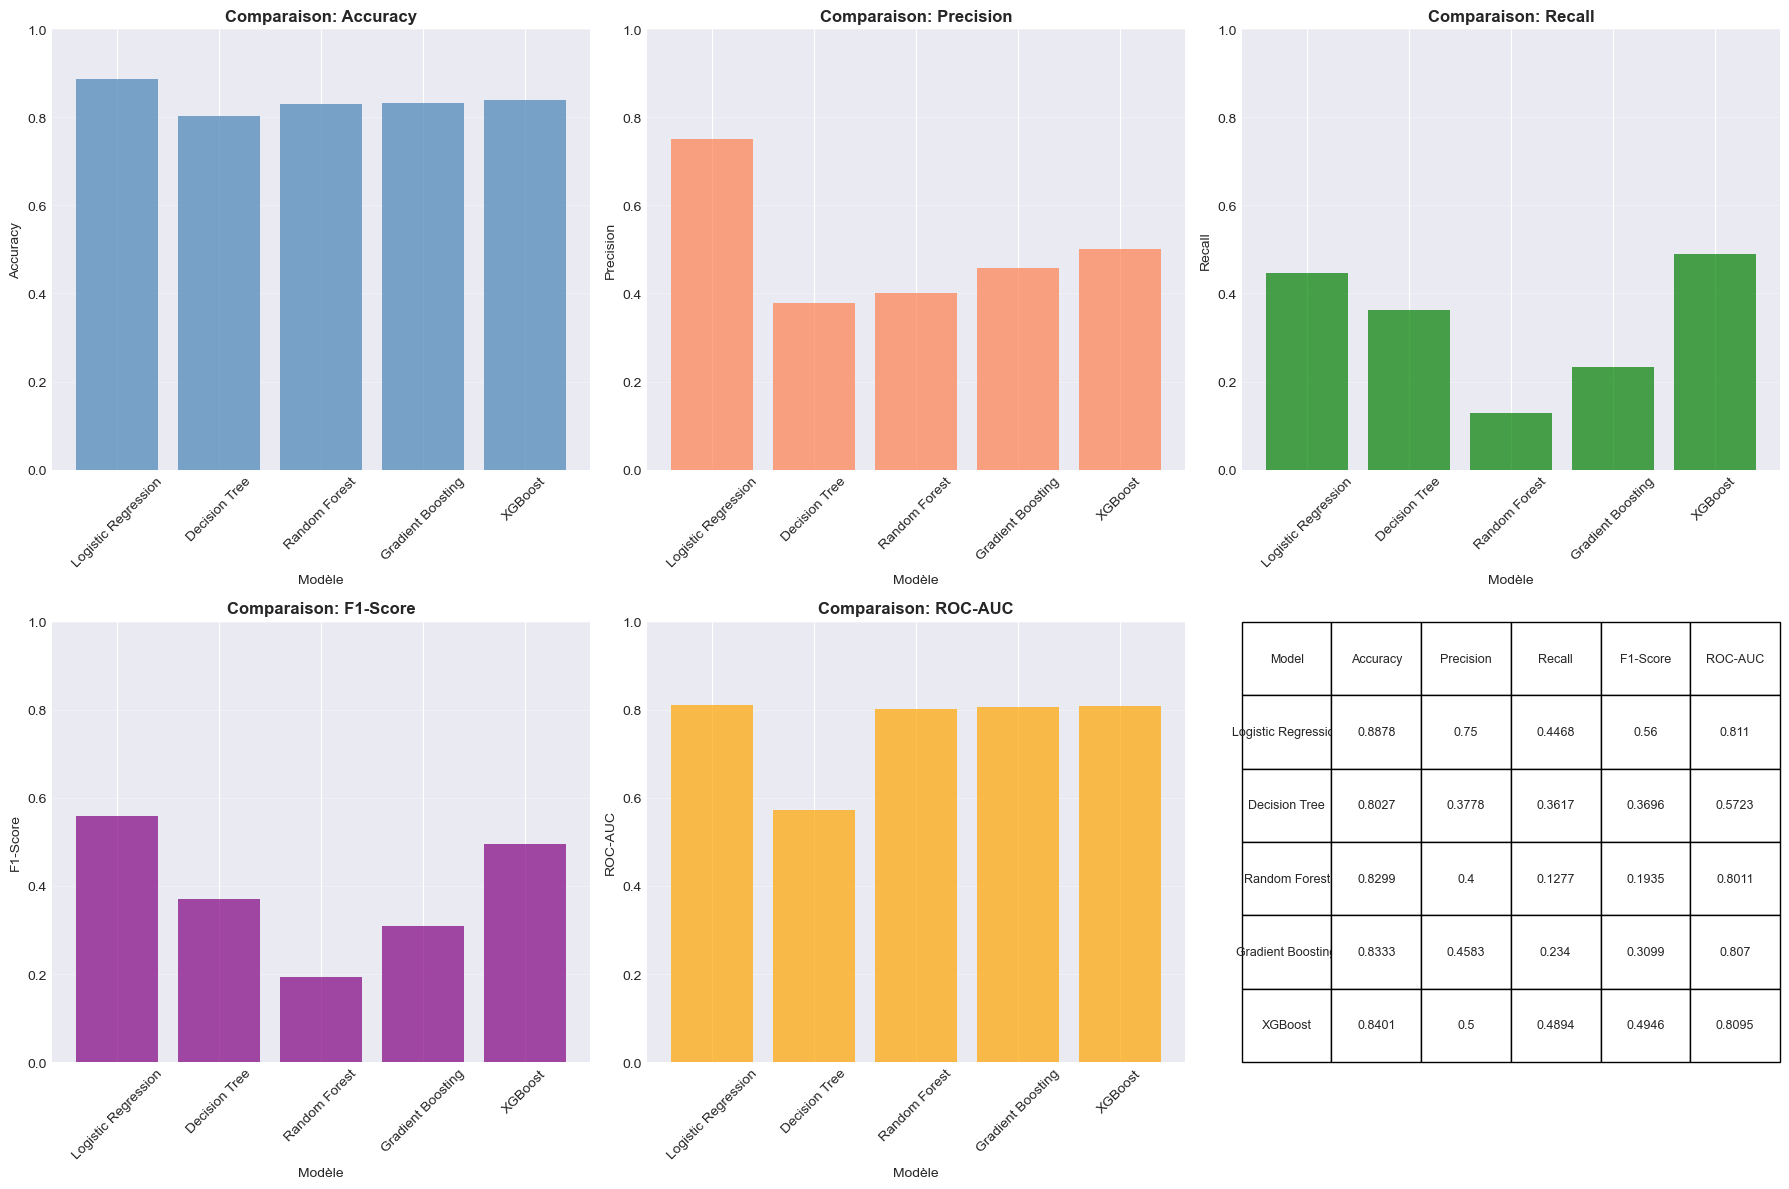

In [90]:
# Identifier le meilleur modèle
best_model_name = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
print(f"\n✓ Meilleur modèle (basé sur F1-Score): {best_model_name}")

# Visualisation comparative
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['steelblue', 'coral', 'green', 'purple', 'orange']

for idx, metric in enumerate(metrics):
    axes[idx].bar(comparison_df['Model'], comparison_df[metric], color=colors[idx], alpha=0.7)
    axes[idx].set_xlabel('Modèle', fontsize=10)
    axes[idx].set_ylabel(metric, fontsize=10)
    axes[idx].set_title(f'Comparaison: {metric}', fontsize=12, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].set_ylim([0, 1])
    axes[idx].grid(True, alpha=0.3, axis='y')

# Graphique global
axes[5].axis('off')
table_data = comparison_df.round(4).values
table = axes[5].table(cellText=table_data, colLabels=comparison_df.columns,
                      cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Graphique sauvegardé: model_comparison.png")


In [91]:
print("\n" + "=" * 60)
print(f"PARTIE 4: ANALYSE DÉTAILLÉE - {best_model_name}")
print("=" * 60)


PARTIE 4: ANALYSE DÉTAILLÉE - Logistic Regression


In [92]:

best_model = results[best_model_name]['model']
best_predictions = results[best_model_name]['predictions']
best_probabilities = results[best_model_name]['probabilities']



1. Matrice de confusion:
[[240   7]
 [ 26  21]]
✓ Graphique sauvegardé: confusion_matrix.png


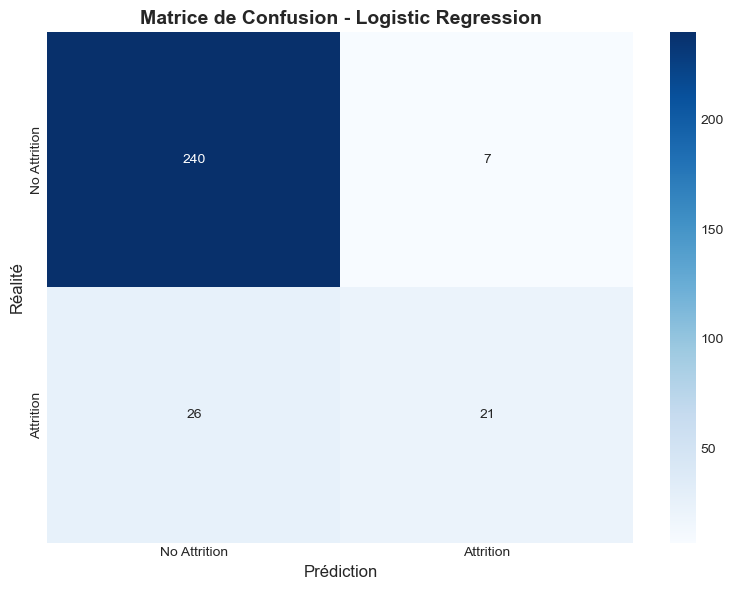

In [93]:
# 1. Matrice de confusion
print("\n1. Matrice de confusion:")
cm = confusion_matrix(y_test, best_predictions)
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])
plt.xlabel('Prédiction', fontsize=12)
plt.ylabel('Réalité', fontsize=12)
plt.title(f'Matrice de Confusion - {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Graphique sauvegardé: confusion_matrix.png")

In [94]:
# 2. Rapport de classification
print("\n2. Rapport de classification:")
print(classification_report(y_test, best_predictions, 
                          target_names=['No Attrition', 'Attrition']))



2. Rapport de classification:
              precision    recall  f1-score   support

No Attrition       0.90      0.97      0.94       247
   Attrition       0.75      0.45      0.56        47

    accuracy                           0.89       294
   macro avg       0.83      0.71      0.75       294
weighted avg       0.88      0.89      0.88       294




3. Courbe ROC:
✓ Graphique sauvegardé: roc_curves.png


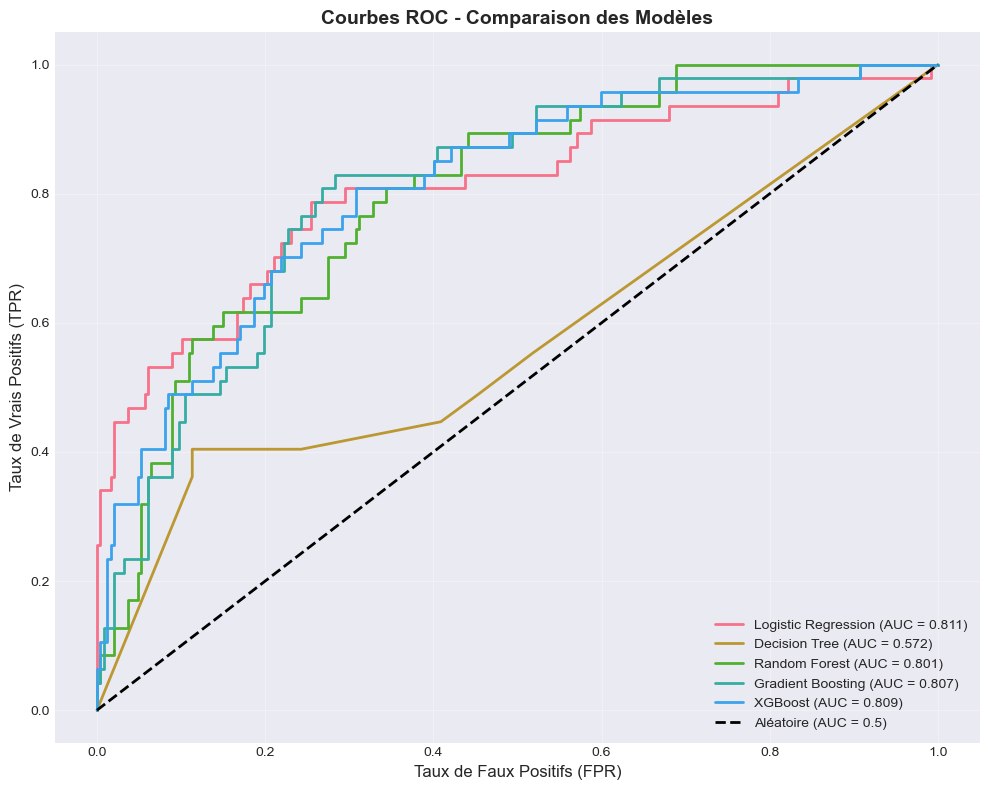

In [95]:
# 3. Courbe ROC
print("\n3. Courbe ROC:")
plt.figure(figsize=(10, 8))

for model_name in results.keys():
    fpr, tpr, _ = roc_curve(y_test, results[model_name]['probabilities'])
    auc = results[model_name]['roc_auc']
    plt.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Aléatoire (AUC = 0.5)')
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbes ROC - Comparaison des Modèles', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
print("✓ Graphique sauvegardé: roc_curves.png")

In [96]:
print("\n" + "=" * 60)
print("PARTIE 5: IMPORTANCE DES FEATURES")
print("=" * 60)


PARTIE 5: IMPORTANCE DES FEATURES


In [98]:
# Pour les modèles basés sur les arbres
if best_model_name in ['Random Forest', 'Gradient Boosting', 'Decision Tree', 'XGBoost']:
    feature_importance = pd.DataFrame({
        'Feature': all_features,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    # Convertir en pourcentage
    feature_importance['Importance_Percent'] = feature_importance['Importance'] * 100
    
    print("\nTop 15 features les plus importantes:")
    print(feature_importance[['Feature', 'Importance_Percent']].head(15).to_string(index=False))
    
    print("\nTop 3 facteurs prédictifs:")
    for i, row in feature_importance.head(3).iterrows():
        print(f"- {row['Feature']} ({row['Importance_Percent']:.1f}%)")
    
    # Visualisation
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['Importance'].values, color='steelblue')
    plt.yticks(range(len(top_features)), top_features['Feature'].values)
    plt.xlabel('Importance', fontsize=12)
    plt.title(f'Top 15 Features - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    print("\n✓ Graphique sauvegardé: feature_importance.png")

In [99]:
print("\n" + "=" * 60)
print("PARTIE 6: ANALYSE DES PRÉDICTIONS")
print("=" * 60)


PARTIE 6: ANALYSE DES PRÉDICTIONS



1. Distribution des niveaux de risque:
  Faible: 239 employés (81.3%)
  Moyen: 37 employés (12.6%)
  Élevé: 18 employés (6.1%)


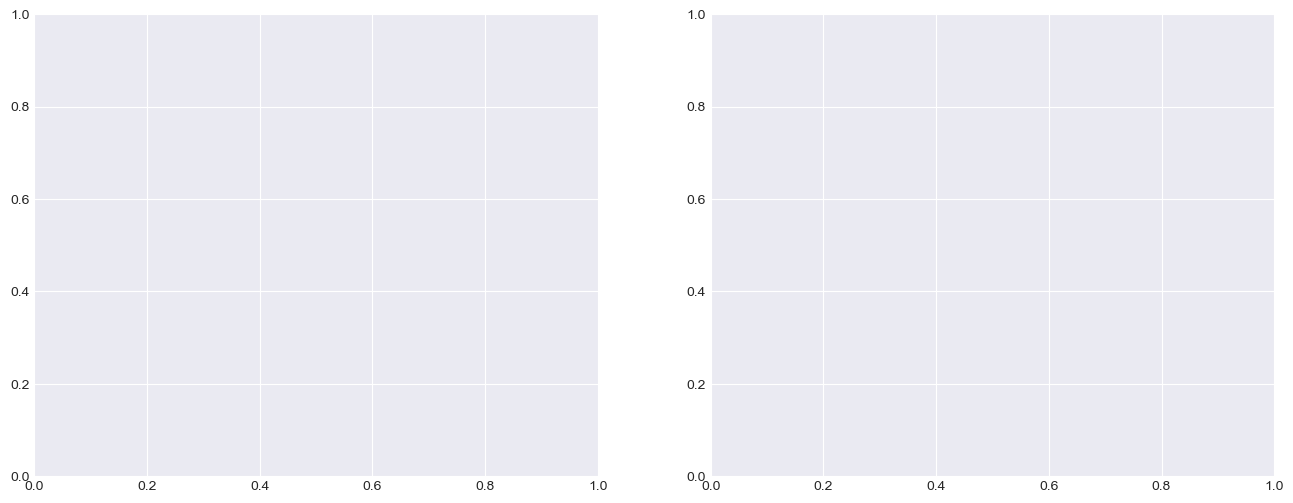

In [100]:
test_results = X_test.copy()
test_results['Attrition_Real'] = y_test.values
test_results['Attrition_Predicted'] = best_predictions
test_results['Attrition_Probability'] = best_probabilities
def risk_category(prob):
    if prob < 0.3:
        return 'Faible'
    elif prob < 0.6:
        return 'Moyen'
    else:
        return 'Élevé'

test_results['Risk_Level'] = test_results['Attrition_Probability'].apply(risk_category)

print("\n1. Distribution des niveaux de risque:")
risk_dist = test_results['Risk_Level'].value_counts()
for level, count in risk_dist.items():
    pct = (count / len(test_results)) * 100
    print(f"  {level}: {count} employés ({pct:.1f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))



1. Distribution des niveaux de risque:
  Faible: 239 employés (81.3%)
  Moyen: 37 employés (12.6%)
  Élevé: 18 employés (6.1%)

✓ Graphique sauvegardé: risk_analysis.png


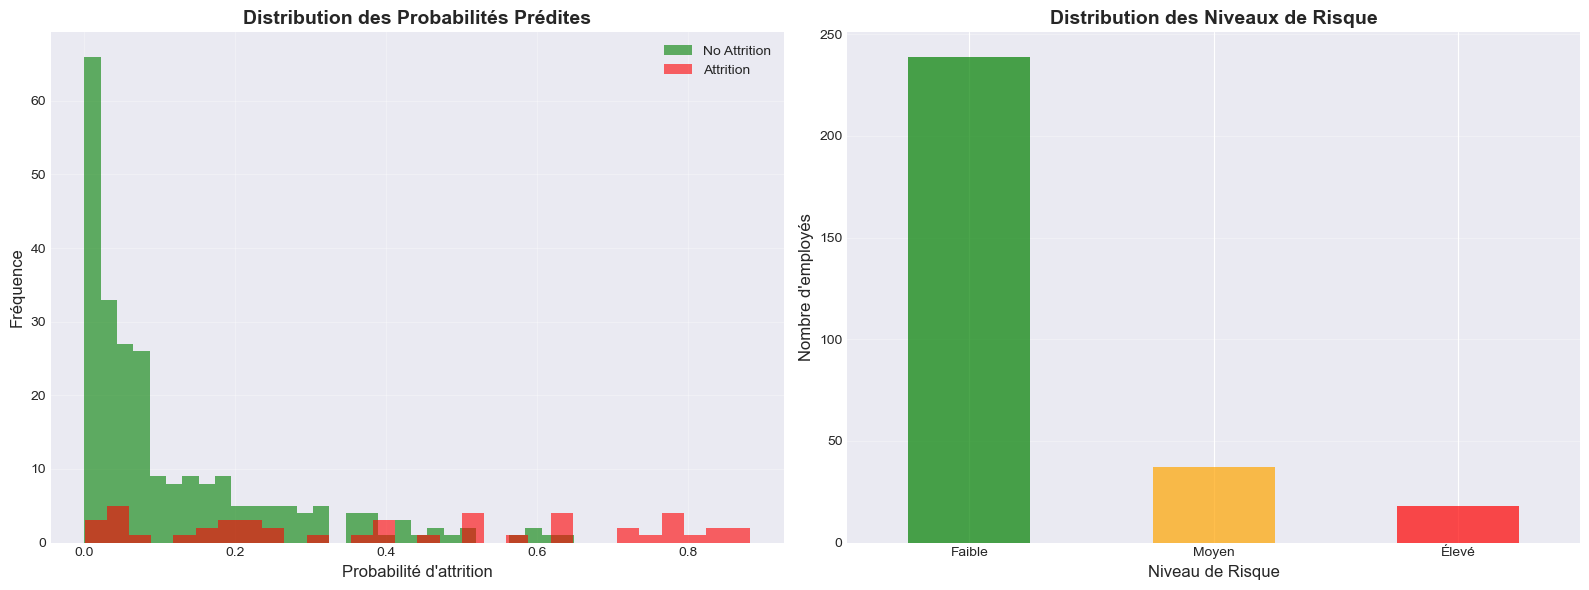

In [101]:
def risk_category(prob):
    if prob < 0.3:
        return 'Faible'
    elif prob < 0.6:
        return 'Moyen'
    else:
        return 'Élevé'

test_results['Risk_Level'] = test_results['Attrition_Probability'].apply(risk_category)

print("\n1. Distribution des niveaux de risque:")
risk_dist = test_results['Risk_Level'].value_counts()
for level, count in risk_dist.items():
    pct = (count / len(test_results)) * 100
    print(f"  {level}: {count} employés ({pct:.1f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution des probabilités
axes[0].hist(test_results[test_results['Attrition_Real']==0]['Attrition_Probability'], 
            bins=30, alpha=0.6, label='No Attrition', color='green')
axes[0].hist(test_results[test_results['Attrition_Real']==1]['Attrition_Probability'], 
            bins=30, alpha=0.6, label='Attrition', color='red')
axes[0].set_xlabel('Probabilité d\'attrition', fontsize=12)
axes[0].set_ylabel('Fréquence', fontsize=12)
axes[0].set_title('Distribution des Probabilités Prédites', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Niveaux de risque
risk_dist.plot(kind='bar', ax=axes[1], color=['green', 'orange', 'red'], alpha=0.7)
axes[1].set_xlabel('Niveau de Risque', fontsize=12)
axes[1].set_ylabel('Nombre d\'employés', fontsize=12)
axes[1].set_title('Distribution des Niveaux de Risque', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('risk_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Graphique sauvegardé: risk_analysis.png")

In [102]:
print("\n" + "=" * 60)
print("RÉSUMÉ FINAL")
print("=" * 60)


RÉSUMÉ FINAL


In [103]:
print(f"✓ {len(results)} modèles entraînés et évalués")
print(f"✓ Meilleur modèle: {best_model_name}")
print(f"✓ Accuracy: {results[best_model_name]['accuracy']*100:.2f}%")
print(f"✓ Precision: {results[best_model_name]['precision']*100:.2f}%")
print(f"✓ Recall: {results[best_model_name]['recall']*100:.2f}%")
print(f"✓ F1-Score: {results[best_model_name]['f1']*100:.2f}%")
print(f"✓ ROC-AUC: {results[best_model_name]['roc_auc']*100:.2f}%")

if best_model_name in ['Random Forest', 'Gradient Boosting', 'Decision Tree', 'XGBoost']:
    feature_importance = pd.DataFrame({
        'Feature': all_features,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n✓ Top 3 facteurs prédictifs:")
    for _, row in feature_importance.head(3).iterrows():
        print(f"  - {row['Feature']} ({row['Importance']*100:.1f}%)")

✓ 5 modèles entraînés et évalués
✓ Meilleur modèle: Logistic Regression
✓ Accuracy: 88.78%
✓ Precision: 75.00%
✓ Recall: 44.68%
✓ F1-Score: 56.00%
✓ ROC-AUC: 81.10%


In [117]:
print("\n" + "=" * 60)
print("PARTIE 7: SAUVEGARDE DES RÉSULTATS")
print("=" * 60)


PARTIE 7: SAUVEGARDE DES RÉSULTATS


In [118]:
test_results.to_csv('attrition_predictions.csv', index=False)
print("✓ Prédictions sauvegardées: attrition_predictions.csv")


✓ Prédictions sauvegardées: attrition_predictions.csv


In [119]:
# Sauvegarder le tableau de comparaison
comparison_df.to_csv('model_comparison.csv', index=False)
print("✓ Comparaison des modèles sauvegardée: model_comparison.csv")

✓ Comparaison des modèles sauvegardée: model_comparison.csv


In [121]:
# Résumé final
print("\n" + "=" * 60)
print("RÉSUMÉ DE LA PRÉDICTION")
print("=" * 60)
print(f"\n✓ {len(results)} modèles entraînés et évalués")
print(f"✓ Meilleur modèle: {best_model_name}")
print(f"✓ Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"✓ F1-Score: {results[best_model_name]['f1']:.4f}")
print(f"✓ ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")
print(f"\n✓ Tous les résultats et graphiques sauvegardés")



RÉSUMÉ DE LA PRÉDICTION

✓ 4 modèles entraînés et évalués
✓ Meilleur modèle: Logistic Regression
✓ Accuracy: 0.8878
✓ F1-Score: 0.5600
✓ ROC-AUC: 0.8110

✓ Tous les résultats et graphiques sauvegardés


In [122]:
print("=" * 60)
print("DSO 3: SYSTÈME DE RECOMMANDATIONS")
print("=" * 60)
print("\n" + "=" * 60)
print("PARTIE 1: CHARGEMENT DES DONNÉES")
print("=" * 60)



DSO 3: SYSTÈME DE RECOMMANDATIONS

PARTIE 1: CHARGEMENT DES DONNÉES


In [123]:
df_with_clusters = pd.read_csv('employees_with_clusters.csv')
print(f"✓ Dataset avec clusters chargé: {df_with_clusters.shape}")

✓ Dataset avec clusters chargé: (1470, 37)


In [124]:
df_predictions = pd.read_csv('attrition_predictions.csv')
print(f"✓ Prédictions chargées: {df_predictions.shape}")


✓ Prédictions chargées: (294, 29)


In [125]:
df_recommendations = df_with_clusters.copy()


In [126]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [127]:

# Préparer les données
df_model = df_recommendations.copy()
df_model['Attrition_Binary'] = (df_model['Attrition'] == 'Yes').astype(int)

# Features
numeric_features = [
    'Age', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction',
    'EnvironmentSatisfaction', 'WorkLifeBalance', 'JobInvolvement',
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
    'NumCompaniesWorked', 'TotalWorkingYears', 'TrainingTimesLastYear',
    'PercentSalaryHike', 'StockOptionLevel', 'DistanceFromHome',
    'JobLevel', 'RelationshipSatisfaction'
]

categorical_features = [
    'BusinessTravel', 'Department', 'EducationField', 'Gender',
    'JobRole', 'MaritalStatus', 'OverTime'
]


In [128]:
# Vérifier les features disponibles
numeric_features = [f for f in numeric_features if f in df_model.columns]
categorical_features = [f for f in categorical_features if f in df_model.columns]


In [129]:
# Encoder les catégorielles
df_encoded = df_model.copy()
for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])


In [130]:
all_features = numeric_features + categorical_features
X_full = df_encoded[all_features]
y_full = df_encoded['Attrition_Binary']


In [131]:
# Entraîner le modèle sur tout le dataset
print("\n1. Entraînement du modèle sur le dataset complet:")
rf_full = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_full.fit(X_full, y_full)
attrition_probabilities = rf_full.predict_proba(X_full)[:, 1]

# Ajouter au dataset
df_recommendations['Attrition_Probability'] = attrition_probabilities
df_recommendations['Attrition_Binary'] = df_model['Attrition_Binary']

print(f"✓ Probabilités d'attrition calculées pour {len(df_recommendations)} employés")



1. Entraînement du modèle sur le dataset complet:
✓ Probabilités d'attrition calculées pour 1470 employés


In [132]:
print("\n" + "=" * 60)
print("PARTIE 2: RÈGLES DE RECOMMANDATION")
print("=" * 60)


PARTIE 2: RÈGLES DE RECOMMANDATION


In [134]:
def generate_recommendations(row):
    """
    Génère des recommandations personnalisées pour un employé
    basées sur son profil, cluster, et risque d'attrition
    """
    recommendations = []
    priority = 'Normal'
    
    # 1. RISQUE D'ATTRITION ÉLEVÉ (Probabilité > 0.6)
    if row['Attrition_Probability'] > 0.6:
        priority = 'URGENT'
        recommendations.append(" RISQUE ÉLEVÉ D'ATTRITION")
        recommendations.append("→ Entretien individuel immédiat avec le manager")
        recommendations.append("→ Révision salariale prioritaire")
        recommendations.append("→ Plan de rétention personnalisé")
    
    # 2. RISQUE MOYEN (Probabilité entre 0.3 et 0.6)
    elif row['Attrition_Probability'] > 0.3:
        priority = 'Moyen'
        recommendations.append(" RISQUE MOYEN D'ATTRITION")
        recommendations.append("→ Suivi régulier avec le manager")
    
    # 3. SATISFACTION AU TRAVAIL FAIBLE (< 2/4)
    if row['JobSatisfaction'] < 2:
        recommendations.append(" Satisfaction au travail faible")
        recommendations.append("→ Évaluation des tâches et responsabilités")
        recommendations.append("→ Possibilité de changement de rôle ou projet")
        recommendations.append("→ Formation pour développement de compétences")
    
    # 4. ÉQUILIBRE VIE-TRAVAIL FAIBLE (< 2/4)
    if row['WorkLifeBalance'] < 2:
        recommendations.append(" Équilibre vie-travail insuffisant")
        recommendations.append("→ Réduction des heures supplémentaires")
        recommendations.append("→ Télétravail ou horaires flexibles")
        recommendations.append("→ Programme de bien-être")
    
    # 5. HEURES SUPPLÉMENTAIRES + MAUVAIS ÉQUILIBRE
    if row['OverTime'] == 'Yes' and row['WorkLifeBalance'] < 3:
        recommendations.append(" Surcharge de travail détectée")
        recommendations.append("→ Redistribution de la charge de travail")
        recommendations.append("→ Embauche d'un support supplémentaire")
    
    # 6. SATISFACTION ENVIRONNEMENT FAIBLE (< 2/4)
    if row['EnvironmentSatisfaction'] < 2:
        recommendations.append(" Insatisfaction environnement de travail")
        recommendations.append("→ Amélioration des conditions de travail")
        recommendations.append("→ Changement d'équipe ou de bureau")
    
    # 7. PAS DE PROMOTION DEPUIS LONGTEMPS (> 5 ans)
    if row['YearsSinceLastPromotion'] > 5:
        recommendations.append(" Stagnation de carrière")
        recommendations.append("→ Plan de développement de carrière")
        recommendations.append("→ Évaluation pour promotion")
        recommendations.append("→ Nouvelles responsabilités")
    
    # 8. SALAIRE FAIBLE PAR RAPPORT À L'EXPÉRIENCE
    avg_income = df_recommendations[
        (df_recommendations['JobLevel'] == row['JobLevel']) &
        (df_recommendations['Department'] == row['Department'])
    ]['MonthlyIncome'].mean()
    
    if row['MonthlyIncome'] < avg_income * 0.85:
        recommendations.append(" Salaire en dessous de la moyenne")
        recommendations.append("→ Révision salariale recommandée")
        recommendations.append("→ Bonus ou avantages supplémentaires")
    
    # 9. FORMATION INSUFFISANTE (< 2 formations/an)
    if row['TrainingTimesLastYear'] < 2:
        recommendations.append(" Formation insuffisante")
        recommendations.append("→ Programme de formation continue")
        recommendations.append("→ Certifications professionnelles")
    
    # 10. DISTANCE DOMICILE-TRAVAIL ÉLEVÉE (> 20 km)
    if row['DistanceFromHome'] > 20:
        recommendations.append(" Distance domicile-travail importante")
        recommendations.append("→ Télétravail partiel ou complet")
        recommendations.append("→ Aide au transport")
    
    # 11. FAIBLE IMPLICATION (< 2/4)
    if row['JobInvolvement'] < 2:
        recommendations.append(" Faible implication au travail")
        recommendations.append("→ Projets stimulants et motivants")
        recommendations.append("→ Reconnaissance et valorisation")
    
    # Si aucune recommandation spécifique
    if len(recommendations) == 0:
        recommendations.append(" Profil stable")
        recommendations.append("→ Maintenir les conditions actuelles")
        recommendations.append("→ Suivi de routine")
    
    return {
        'recommendations': recommendations,
        'priority': priority,
        'num_actions': len(recommendations)
    }

print("\n✓ Règles de recommandation définies:")
print("  - Risque d'attrition (3 niveaux)")
print("  - Satisfaction au travail")
print("  - Équilibre vie-travail")
print("  - Heures supplémentaires")
print("  - Satisfaction environnement")
print("  - Stagnation de carrière")
print("  - Salaire vs moyenne")
print("  - Formation")
print("  - Distance domicile-travail")
print("  - Implication au travail")


✓ Règles de recommandation définies:
  - Risque d'attrition (3 niveaux)
  - Satisfaction au travail
  - Équilibre vie-travail
  - Heures supplémentaires
  - Satisfaction environnement
  - Stagnation de carrière
  - Salaire vs moyenne
  - Formation
  - Distance domicile-travail
  - Implication au travail


In [135]:
print("\n" + "=" * 60)
print("PARTIE 3: GÉNÉRATION DES RECOMMANDATIONS")
print("=" * 60)


PARTIE 3: GÉNÉRATION DES RECOMMANDATIONS


In [136]:
print("\n1. Génération des recommandations pour tous les employés...")
recommendations_list = []

for idx, row in df_recommendations.iterrows():
    rec = generate_recommendations(row)
    recommendations_list.append({
        'EmployeeNumber': row['EmployeeNumber'],
        'Age': row['Age'],
        'Department': row['Department'],
        'JobRole': row['JobRole'],
        'Cluster': row['Cluster_KMeans'],
        'Attrition_Probability': row['Attrition_Probability'],
        'Priority': rec['priority'],
        'Num_Actions': rec['num_actions'],
        'Recommendations': ' | '.join(rec['recommendations'])
    })

df_final_recommendations = pd.DataFrame(recommendations_list)
print(f"✓ Recommandations générées pour {len(df_final_recommendations)} employés")



1. Génération des recommandations pour tous les employés...
✓ Recommandations générées pour 1470 employés


In [137]:
print("\n" + "=" * 60)
print("PARTIE 4: ANALYSE DES RECOMMANDATIONS")
print("=" * 60)


PARTIE 4: ANALYSE DES RECOMMANDATIONS


In [138]:
# 1. Distribution par priorité
print("\n1. Distribution par niveau de priorité:")
priority_dist = df_final_recommendations['Priority'].value_counts()
for priority, count in priority_dist.items():
    pct = (count / len(df_final_recommendations)) * 100
    print(f"  {priority}: {count} employés ({pct:.1f}%)")


1. Distribution par niveau de priorité:
  Normal: 1233 employés (83.9%)
  URGENT: 169 employés (11.5%)
  Moyen: 68 employés (4.6%)


In [139]:
# 2. Statistiques par cluster
print("\n2. Recommandations par cluster:")
cluster_stats = df_final_recommendations.groupby('Cluster').agg({
    'Attrition_Probability': 'mean',
    'Num_Actions': 'mean',
    'EmployeeNumber': 'count'
}).round(3)
cluster_stats.columns = ['Prob_Attrition_Moyenne', 'Actions_Moyennes', 'Nombre_Employés']
print(cluster_stats)



2. Recommandations par cluster:
         Prob_Attrition_Moyenne  Actions_Moyennes  Nombre_Employés
Cluster                                                           
0                         0.095             5.632              487
1                         0.192             5.200              983


In [140]:
print("\n3. Top 10 employés à risque URGENT:")
urgent_employees = df_final_recommendations[
    df_final_recommendations['Priority'] == 'URGENT'
].sort_values('Attrition_Probability', ascending=False).head(10)

print(urgent_employees[['EmployeeNumber', 'Department', 'JobRole', 
                        'Attrition_Probability', 'Num_Actions']].to_string(index=False))


3. Top 10 employés à risque URGENT:
 EmployeeNumber             Department               JobRole  Attrition_Probability  Num_Actions
            959                  Sales  Sales Representative               0.967091           10
            614                  Sales  Sales Representative               0.959574            7
            167                  Sales  Sales Representative               0.937091           13
           1624                  Sales  Sales Representative               0.928261            7
            622 Research & Development Laboratory Technician               0.923667           20
           1783 Research & Development Laboratory Technician               0.921668           11
           1016 Research & Development    Research Scientist               0.915110            8
           1868 Research & Development    Research Scientist               0.912042           10
             19 Research & Development Laboratory Technician               0.902050       

In [141]:
print("\n" + "=" * 60)
print("PARTIE 5: VISUALISATIONS")
print("=" * 60)


PARTIE 5: VISUALISATIONS


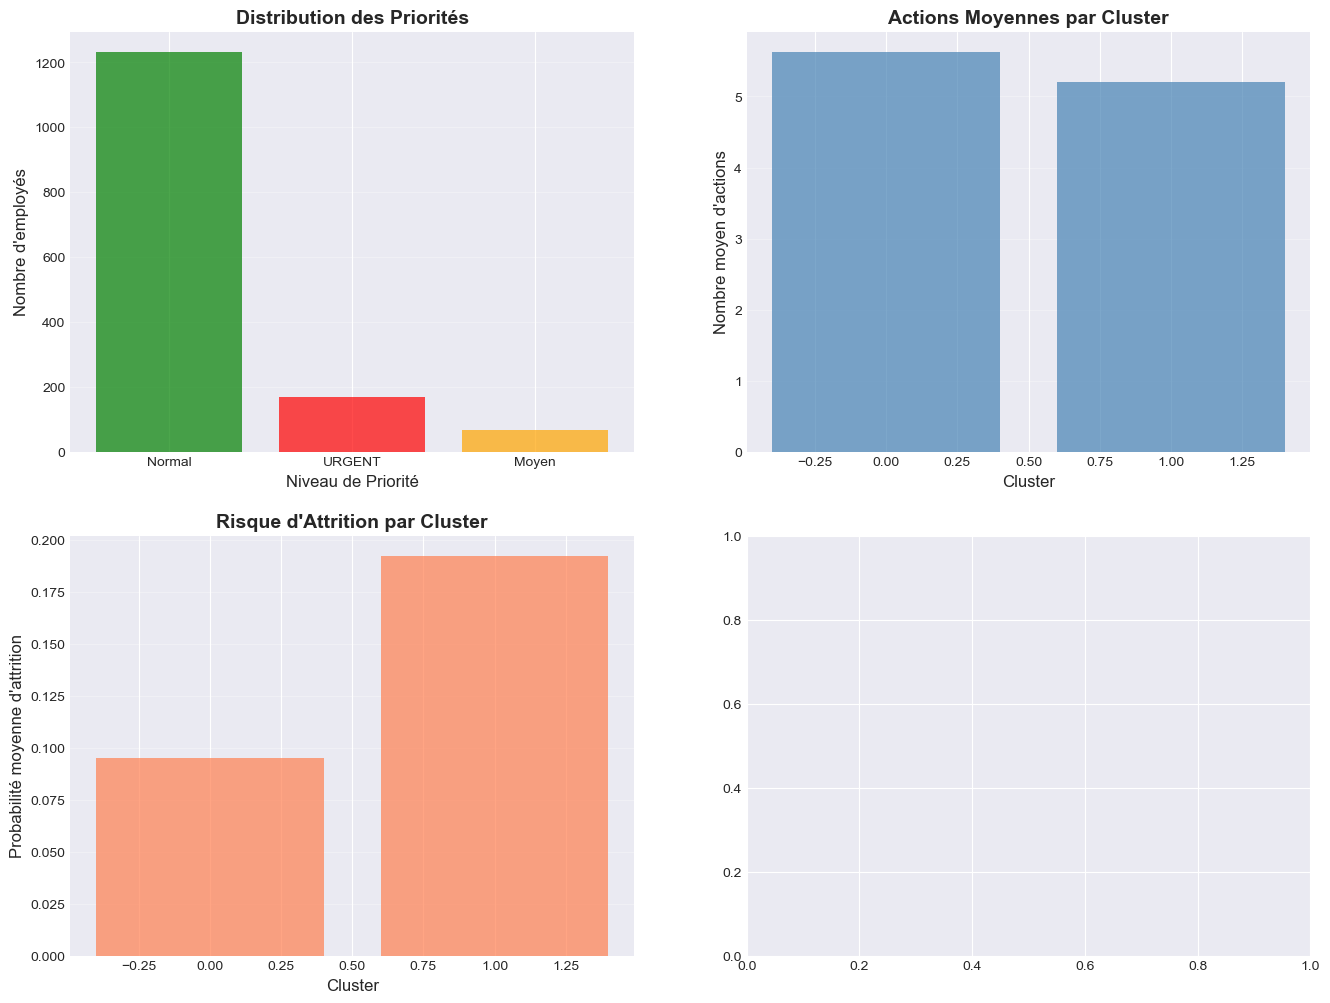

In [144]:
# 1. Distribution des priorités
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Priorités
priority_colors = {'URGENT': 'red', 'Moyen': 'orange', 'Normal': 'green'}
colors = [priority_colors.get(p, 'gray') for p in priority_dist.index]
axes[0, 0].bar(priority_dist.index, priority_dist.values, color=colors, alpha=0.7)
axes[0, 0].set_xlabel('Niveau de Priorité', fontsize=12)
axes[0, 0].set_ylabel('Nombre d\'employés', fontsize=12)
axes[0, 0].set_title('Distribution des Priorités', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Nombre d'actions par cluster
cluster_actions = df_final_recommendations.groupby('Cluster')['Num_Actions'].mean()
axes[0, 1].bar(cluster_actions.index, cluster_actions.values, color='steelblue', alpha=0.7)
axes[0, 1].set_xlabel('Cluster', fontsize=12)
axes[0, 1].set_ylabel('Nombre moyen d\'actions', fontsize=12)
axes[0, 1].set_title('Actions Moyennes par Cluster', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Probabilité d'attrition par cluster
cluster_prob = df_final_recommendations.groupby('Cluster')['Attrition_Probability'].mean()
axes[1, 0].bar(cluster_prob.index, cluster_prob.values, color='coral', alpha=0.7)
axes[1, 0].set_xlabel('Cluster', fontsize=12)
axes[1, 0].set_ylabel('Probabilité moyenne d\'attrition', fontsize=12)
axes[1, 0].set_title('Risque d\'Attrition par Cluster', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')




✓ Graphique sauvegardé: recommendations_analysis.png

2. Analyse par département:
✓ Graphique sauvegardé: priority_by_department.png


<Figure size 640x480 with 0 Axes>

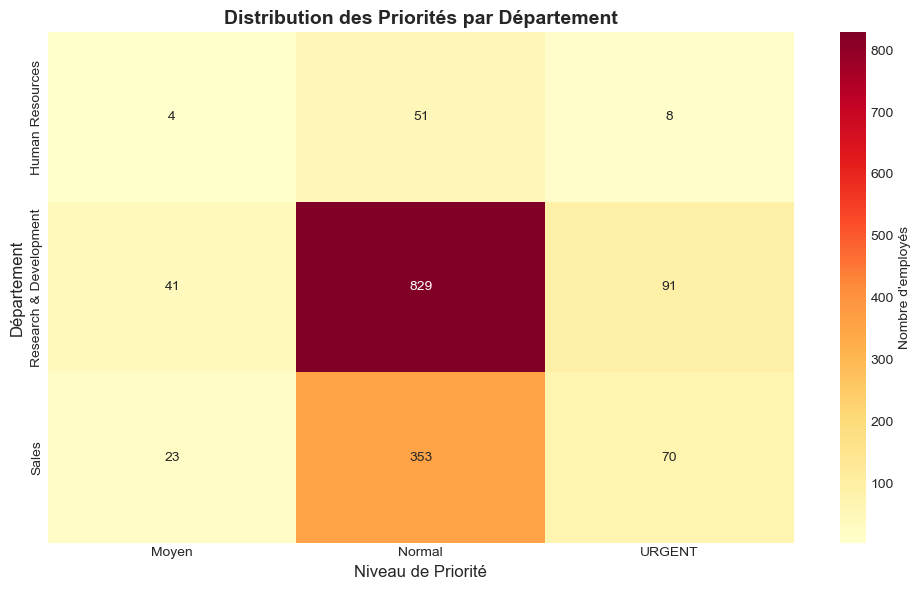

In [145]:
# Distribution des probabilités par priorité
for priority in ['URGENT', 'Moyen', 'Normal']:
    data = df_final_recommendations[df_final_recommendations['Priority'] == priority]['Attrition_Probability']
    axes[1, 1].hist(data, bins=20, alpha=0.5, label=priority, 
                   color=priority_colors.get(priority, 'gray'))

axes[1, 1].set_xlabel('Probabilité d\'attrition', fontsize=12)
axes[1, 1].set_ylabel('Fréquence', fontsize=12)
axes[1, 1].set_title('Distribution des Probabilités par Priorité', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('recommendations_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Graphique sauvegardé: recommendations_analysis.png")

# 2. Heatmap: Priorité par Département
print("\n2. Analyse par département:")
dept_priority = pd.crosstab(df_final_recommendations['Department'], 
                            df_final_recommendations['Priority'])

plt.figure(figsize=(10, 6))
sns.heatmap(dept_priority, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Nombre d\'employés'})
plt.xlabel('Niveau de Priorité', fontsize=12)
plt.ylabel('Département', fontsize=12)
plt.title('Distribution des Priorités par Département', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('priority_by_department.png', dpi=300, bbox_inches='tight')
print("✓ Graphique sauvegardé: priority_by_department.png")


In [146]:
print("\n" + "=" * 60)
print("PARTIE 6: EXEMPLES DE RECOMMANDATIONS DÉTAILLÉES")
print("=" * 60)



PARTIE 6: EXEMPLES DE RECOMMANDATIONS DÉTAILLÉES


In [147]:
# Afficher 5 exemples d'employés avec recommandations complètes
print("\n EXEMPLES DE RECOMMANDATIONS PERSONNALISÉES:\n")

# 1 URGENT, 1 Moyen, 1 Normal
examples = []
for priority in ['URGENT', 'Moyen', 'Normal']:
    sample = df_final_recommendations[df_final_recommendations['Priority'] == priority].head(1)
    if not sample.empty:
        examples.append(sample.iloc[0])

for i, emp in enumerate(examples, 1):
    print(f"\n{'='*60}")
    print(f"EMPLOYÉ #{i} - ID: {emp['EmployeeNumber']}")
    print(f"{'='*60}")
    print(f"Département: {emp['Department']}")
    print(f"Poste: {emp['JobRole']}")
    print(f"Cluster: {emp['Cluster']}")
    print(f"Probabilité d'attrition: {emp['Attrition_Probability']:.2%}")
    print(f"Priorité: {emp['Priority']}")
    print(f"\nRECOMMANDATIONS:")
    for rec in emp['Recommendations'].split(' | '):
        print(f"  {rec}")



 EXEMPLES DE RECOMMANDATIONS PERSONNALISÉES:


EMPLOYÉ #1 - ID: 1
Département: Sales
Poste: Sales Executive
Cluster: 1
Probabilité d'attrition: 78.02%
Priorité: URGENT

RECOMMANDATIONS:
   RISQUE ÉLEVÉ D'ATTRITION
  → Entretien individuel immédiat avec le manager
  → Révision salariale prioritaire
  → Plan de rétention personnalisé
   Équilibre vie-travail insuffisant
  → Réduction des heures supplémentaires
  → Télétravail ou horaires flexibles
  → Programme de bien-être
   Surcharge de travail détectée
  → Redistribution de la charge de travail
  → Embauche d'un support supplémentaire
   Formation insuffisante
  → Programme de formation continue
  → Certifications professionnelles

EMPLOYÉ #2 - ID: 31
Département: Research & Development
Poste: Research Scientist
Cluster: 1
Probabilité d'attrition: 36.22%
Priorité: Moyen

RECOMMANDATIONS:
   RISQUE MOYEN D'ATTRITION
  → Suivi régulier avec le manager
   Satisfaction au travail faible
  → Évaluation des tâches et responsabilités
  → P

In [148]:
print("\n" + "=" * 60)
print("PARTIE 7: PLAN D'ACTION GLOBAL")
print("=" * 60)


PARTIE 7: PLAN D'ACTION GLOBAL


In [149]:
# Créer un plan d'action par département
print("\n PLAN D'ACTION PAR DÉPARTEMENT:\n")

for dept in df_final_recommendations['Department'].unique():
    dept_data = df_final_recommendations[df_final_recommendations['Department'] == dept]
    urgent_count = (dept_data['Priority'] == 'URGENT').sum()
    avg_prob = dept_data['Attrition_Probability'].mean()
    
    print(f"\n{dept}:")
    print(f"  Total employés: {len(dept_data)}")
    print(f"  Cas URGENTS: {urgent_count} ({urgent_count/len(dept_data)*100:.1f}%)")
    print(f"  Risque moyen: {avg_prob:.2%}")
    
    if urgent_count > 0:
        print(f"   ACTION PRIORITAIRE REQUISE")



 PLAN D'ACTION PAR DÉPARTEMENT:


Sales:
  Total employés: 446
  Cas URGENTS: 70 (15.7%)
  Risque moyen: 19.32%
   ACTION PRIORITAIRE REQUISE

Research & Development:
  Total employés: 961
  Cas URGENTS: 91 (9.5%)
  Risque moyen: 14.30%
   ACTION PRIORITAIRE REQUISE

Human Resources:
  Total employés: 63
  Cas URGENTS: 8 (12.7%)
  Risque moyen: 18.50%
   ACTION PRIORITAIRE REQUISE


In [150]:
print("\n" + "=" * 60)
print("PARTIE 8: SAUVEGARDE DES RÉSULTATS")
print("=" * 60)


PARTIE 8: SAUVEGARDE DES RÉSULTATS


In [151]:
# Sauvegarder toutes les recommandations
df_final_recommendations.to_csv('employee_recommendations.csv', index=False)
print("✓ Recommandations sauvegardées: employee_recommendations.csv")

# Sauvegarder uniquement les cas URGENTS
urgent_cases = df_final_recommendations[df_final_recommendations['Priority'] == 'URGENT']
urgent_cases.to_csv('urgent_cases.csv', index=False)
print(f"✓ Cas urgents sauvegardés: urgent_cases.csv ({len(urgent_cases)} employés)")

✓ Recommandations sauvegardées: employee_recommendations.csv
✓ Cas urgents sauvegardés: urgent_cases.csv (169 employés)


In [152]:
summary_report = {
    'Total_Employees': len(df_final_recommendations),
    'Urgent_Cases': (df_final_recommendations['Priority'] == 'URGENT').sum(),
    'Medium_Cases': (df_final_recommendations['Priority'] == 'Moyen').sum(),
    'Normal_Cases': (df_final_recommendations['Priority'] == 'Normal').sum(),
    'Avg_Attrition_Probability': df_final_recommendations['Attrition_Probability'].mean(),
    'Avg_Actions_Per_Employee': df_final_recommendations['Num_Actions'].mean()
}

summary_df = pd.DataFrame([summary_report])
summary_df.to_csv('recommendations_summary.csv', index=False)
print("✓ Résumé sauvegardé: recommendations_summary.csv")

✓ Résumé sauvegardé: recommendations_summary.csv


In [153]:
print("\n" + "=" * 60)
print("RÉSUMÉ FINAL - SYSTÈME DE RECOMMANDATIONS")
print("=" * 60)

print(f"\n STATISTIQUES GLOBALES:")
print(f"  Total employés analysés: {summary_report['Total_Employees']}")
print(f"  Cas URGENTS: {summary_report['Urgent_Cases']} ({summary_report['Urgent_Cases']/summary_report['Total_Employees']*100:.1f}%)")
print(f"  Cas MOYENS: {summary_report['Medium_Cases']} ({summary_report['Medium_Cases']/summary_report['Total_Employees']*100:.1f}%)")
print(f"  Cas NORMAUX: {summary_report['Normal_Cases']} ({summary_report['Normal_Cases']/summary_report['Total_Employees']*100:.1f}%)")
print(f"  Probabilité moyenne d'attrition: {summary_report['Avg_Attrition_Probability']:.2%}")
print(f"  Actions moyennes par employé: {summary_report['Avg_Actions_Per_Employee']:.1f}")

print(f"\n LIVRABLES CRÉÉS:")
print(f"  ✓ employee_recommendations.csv - Toutes les recommandations")
print(f"  ✓ urgent_cases.csv - Cas prioritaires")
print(f"  ✓ recommendations_summary.csv - Résumé exécutif")
print(f"  ✓ recommendations_analysis.png - Visualisations")
print(f"  ✓ priority_by_department.png - Analyse départementale")

print(f"\n PROCHAINES ÉTAPES RECOMMANDÉES:")
print(f"  1. Traiter en priorité les {summary_report['Urgent_Cases']} cas URGENTS")
print(f"  2. Planifier des entretiens individuels")
print(f"  3. Réviser les politiques de rétention")
print(f"  4. Mettre en place un suivi mensuel")
print(f"  5. Évaluer l'impact des actions après 3-6 mois")

print("\n" + "=" * 60)
print(" PROJET COMPLET TERMINÉ AVEC SUCCÈS!")
print("=" * 60)


RÉSUMÉ FINAL - SYSTÈME DE RECOMMANDATIONS

 STATISTIQUES GLOBALES:
  Total employés analysés: 1470
  Cas URGENTS: 169 (11.5%)
  Cas MOYENS: 68 (4.6%)
  Cas NORMAUX: 1233 (83.9%)
  Probabilité moyenne d'attrition: 16.01%
  Actions moyennes par employé: 5.3

 LIVRABLES CRÉÉS:
  ✓ employee_recommendations.csv - Toutes les recommandations
  ✓ urgent_cases.csv - Cas prioritaires
  ✓ recommendations_summary.csv - Résumé exécutif
  ✓ recommendations_analysis.png - Visualisations
  ✓ priority_by_department.png - Analyse départementale

 PROCHAINES ÉTAPES RECOMMANDÉES:
  1. Traiter en priorité les 169 cas URGENTS
  2. Planifier des entretiens individuels
  3. Réviser les politiques de rétention
  4. Mettre en place un suivi mensuel
  5. Évaluer l'impact des actions après 3-6 mois

 PROJET COMPLET TERMINÉ AVEC SUCCÈS!
